In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib widget

In [3]:
data_dir = '/mnt/home/srafilson/code/sequences/results_all_cells_20ms/full_fit/N_101'
restarts = os.listdir(data_dir)
restarts = [f for f in restarts if f.startswith("restart_")]
likelihoods = np.zeros(len(restarts))
print(f"Found {len(restarts)} restarts")
nMissing = 0
for restart in restarts:
    data_path = f"{data_dir}/{restart}/fitted_model.npz"
    if not os.path.exists(data_path):
        nMissing += 1
        print(f"Missing data for {restart}")
        continue
    data = np.load(data_path, allow_pickle=True)
    likelihoods[restarts.index(restart)] = data["training_likelihoods"][-1]

# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf

print(f"Missing data for {nMissing} restarts / {len(restarts)} total restarts")

# save the likelihoods to np file
np.save(f"{data_dir}/likelihoods.npy", likelihoods)

Found 2000 restarts
Missing data for 0 restarts / 2000 total restarts


In [4]:
# load the likelihoods from the np file
likelihoods = np.load(f"{data_dir}/likelihoods.npy")

In [5]:
# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf

In [6]:
sns.set_context('talk')

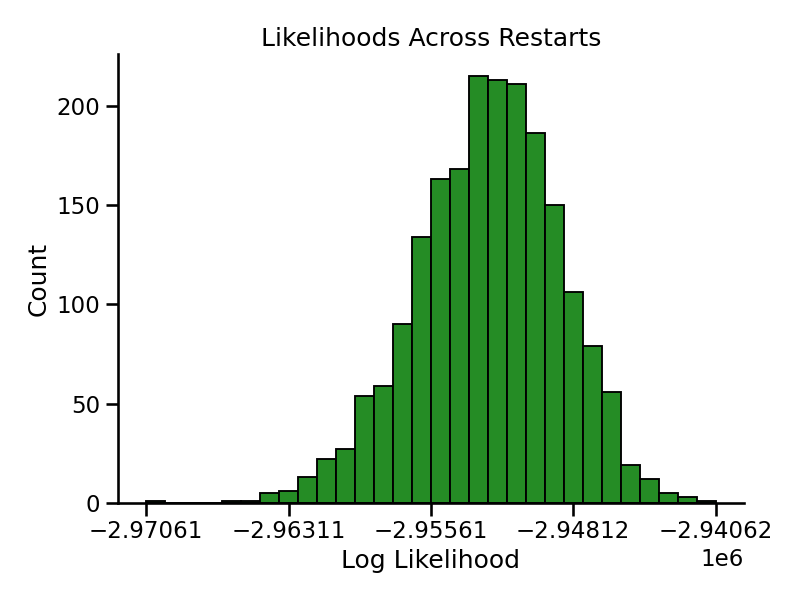

In [7]:

# plot the distribution of likelihoods across restarts
plt.figure(figsize=(8, 6))
sns.histplot(likelihoods, bins=30, color="forestgreen", alpha = 0.99)
plt.xlabel("Log Likelihood")
plt.title("Likelihoods Across Restarts")
# only show 5 x ticks for better visualization
min = np.min(likelihoods[likelihoods != -np.inf])
max = np.max(likelihoods)
plt.xticks(np.linspace(min, max, 5))
plt.tight_layout()
sns.despine()
plt.show()


In [8]:
# get the best likelihood and corresponding parameters
best_idx = np.argmax(likelihoods)

print(f"Best likelihood: {likelihoods[best_idx]} at restart {restarts[best_idx]}")

# get the parameters for the best fit
best_restart = restarts[best_idx]
best_data_path = f"{data_dir}/{best_restart}/fitted_model.npz"
best_data = np.load(best_data_path, allow_pickle=True)

A = best_data["A"]
B = best_data["B"]
pi = best_data["pi"]
training_llh = best_data["training_likelihoods"]

print(B.shape)


# Reorder observation columns (neurons) according to the state that emits each observation with the highest probability.
state_order = np.argsort(np.argmax(B, axis=0))
B_sorted = B[:, state_order]

# normalize so area under each column is 1
B_sorted_normalized = stats.zscore(B_sorted, axis=0)



Best likelihood: -2940619.5830143546 at restart restart_1601
(101, 307)


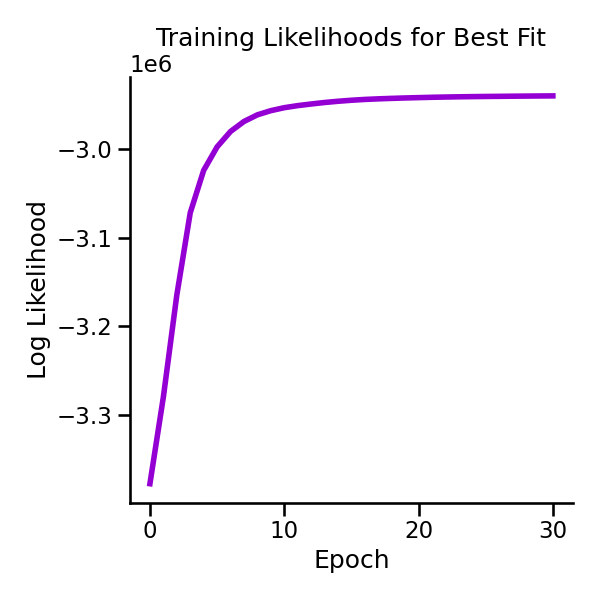

In [9]:
# plot the training likelihoods
plt.figure(figsize=(6, 6))
plt.plot(training_llh, linewidth=4, color = 'darkviolet')
plt.xlabel("Epoch")
plt.ylabel("Log Likelihood")
plt.title("Training Likelihoods for Best Fit")
plt.tight_layout()
sns.despine()
plt.show()


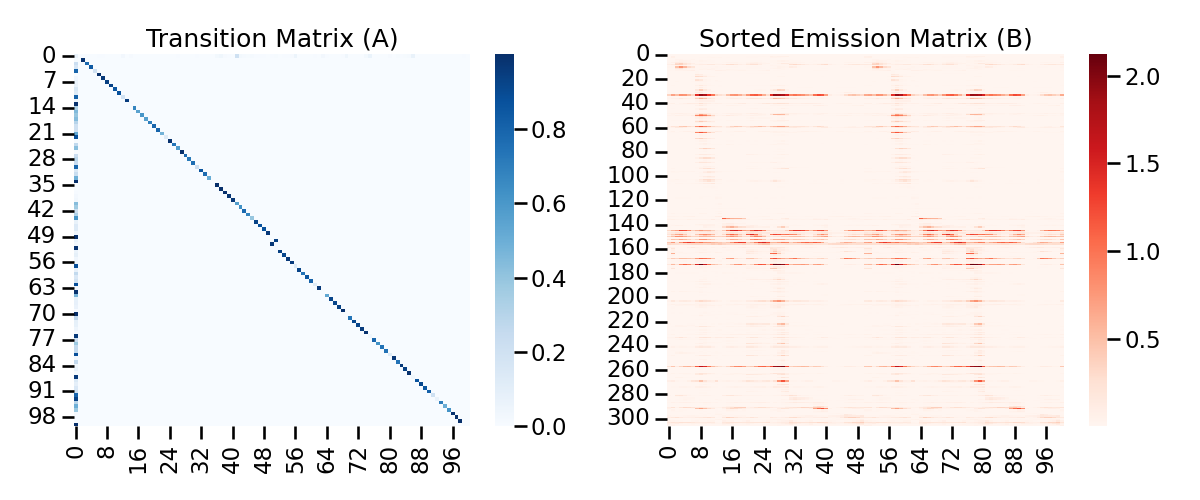

In [10]:
# plot the A and B matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(A, ax=axs[0], cmap="Blues")
axs[0].set_title("Transition Matrix (A)")
sns.heatmap(B_sorted.T, ax=axs[1], cmap="Reds")
axs[1].set_title("Sorted Emission Matrix (B)")
plt.tight_layout()
plt.show()  

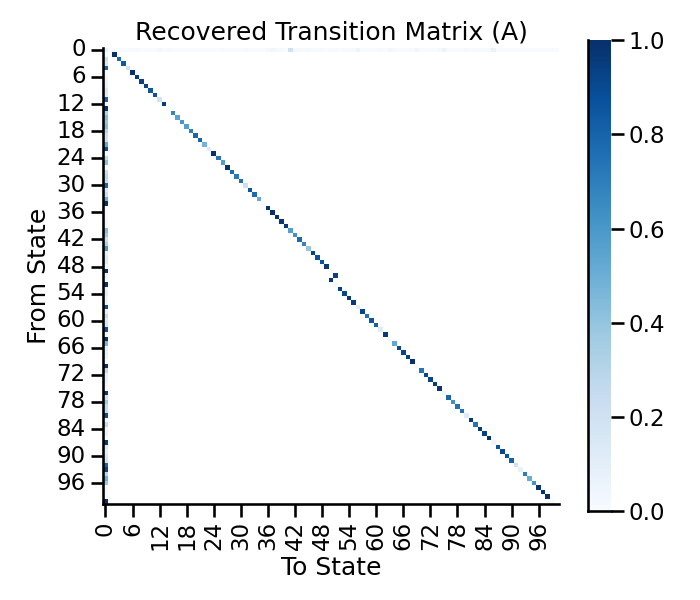

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# copy Blues and force zero to white
cmap = plt.cm.Blues.copy()
cmap.set_under("white")

plt.figure(figsize=(7, 6))
sns.heatmap(
    A,
    cmap=cmap,
    vmin=1e-12,   # values below this use set_under color
    vmax=1,
    square=True
)

plt.title("Recovered Transition Matrix (A)")
plt.xlabel("To State")
plt.ylabel("From State")
plt.tight_layout()
sns.despine()
plt.show()

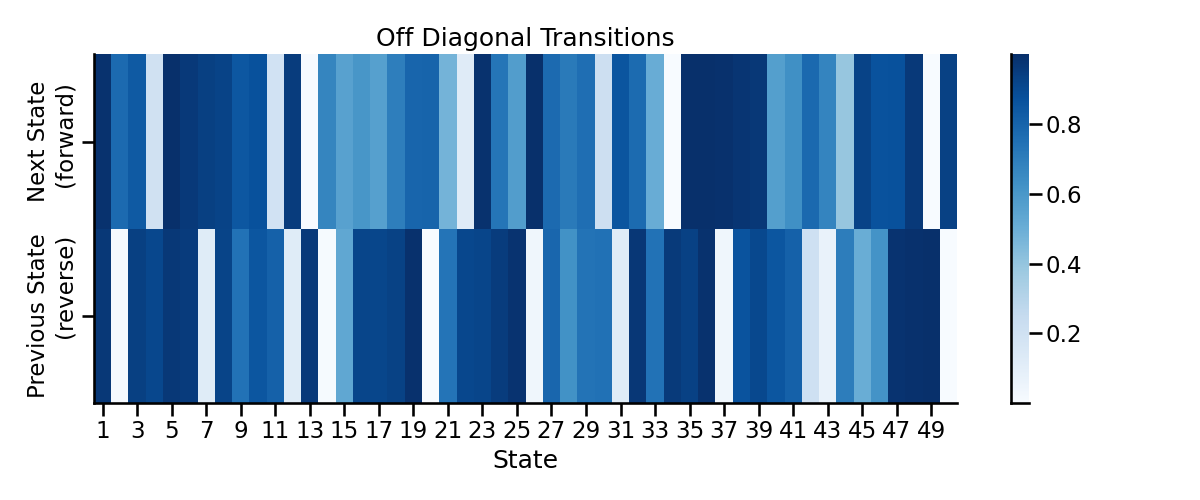

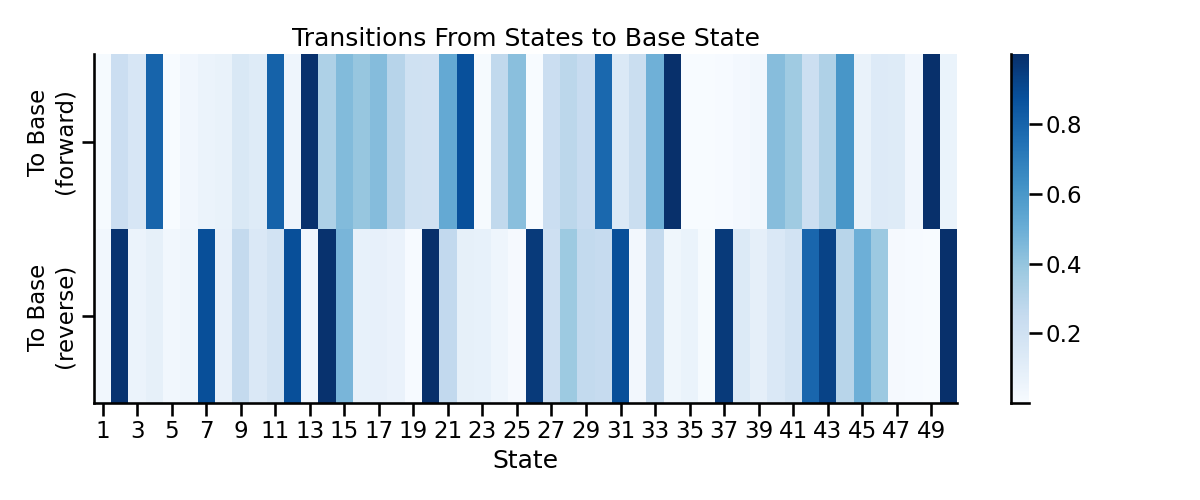

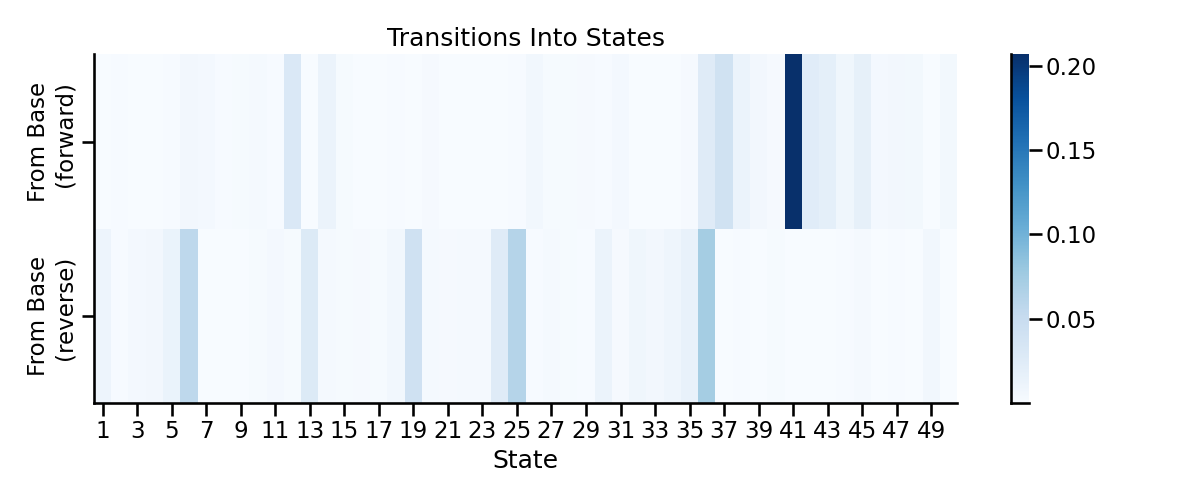

In [12]:



# plot a heatmap with 4 rows and nStates - 1 // 2 columns showing just the state transitions that are non zero
rows = 6
columns = (A.shape[0] - 1) // 2
non_zero_transitions = np.zeros((rows, columns))
for i in range(rows):
    for j in range(columns):
        if i in [0, 1]: # this is for looking at the off diagonal entries
            offset = 1 if i == 0 else columns + 1
            if i == 0:
                non_zero_transitions[i, j] = A[j + offset, j + 2]
            elif i == 1:
                non_zero_transitions[i, j] = A[j + offset, j + columns]

        elif i in [2, 3]: # this is for looking at the first column (transitions from state to the base state)
            non_zero_transitions[i, j] = A[j + 1, 0] if i == 2 else A[j + columns + 1, 0]

        elif i in [4, 5]: # this is for looking at the first row (transitions into any state from the base state)
            non_zero_transitions[i, j] = A[0, j + 1] if i == 4 else A[0, j + columns + 1]

# plot transitions from state to state (off diagonal entries)
plt.figure(figsize=(12, 5))
sns.heatmap(non_zero_transitions[:2, :], cmap="Blues")
plt.title("Off Diagonal Transitions")
plt.xlabel("State")
plt.yticks([0.5, 1.5], ["Next State\n(forward)", "Previous State\n(reverse)"])
plt.xticks(np.arange(0, columns, 2) + 0.5, np.arange(1, columns + 1, 2))
plt.tight_layout()
sns.despine()
plt.show()

# plot the transitions from the states to the base state
plt.figure(figsize=(12, 5))
sns.heatmap(non_zero_transitions[2:4, :], cmap="Blues")
plt.title("Transitions From States to Base State")
plt.xlabel("State")
plt.yticks([0.5, 1.5], ["To Base\n(forward)", "To Base\n(reverse)"])
plt.xticks(np.arange(0, columns, 2) + 0.5, np.arange(1, columns + 1, 2))
plt.tight_layout()
sns.despine()
plt.show()

# plot the transitions into the states
plt.figure(figsize=(12, 5))
sns.heatmap(non_zero_transitions[4:6, :], cmap="Blues")
plt.title("Transitions Into States")
plt.xlabel("State")
plt.yticks([0.5, 1.5], ["From Base\n(forward)", "From Base\n(reverse)"])
plt.xticks(np.arange(0, columns, 2) + 0.5, np.arange(1, columns + 1, 2))
plt.tight_layout()
sns.despine()
plt.show()




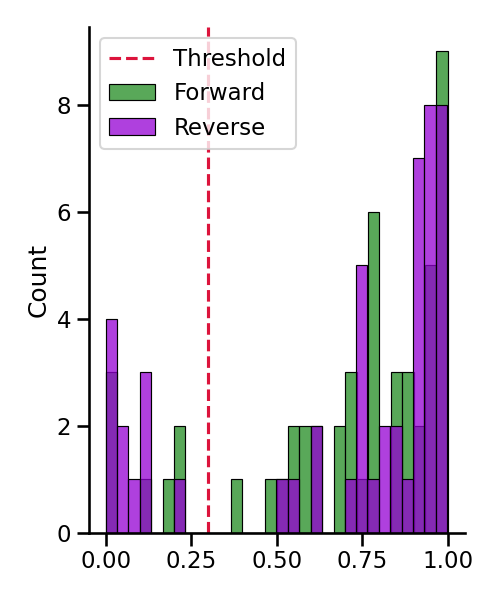

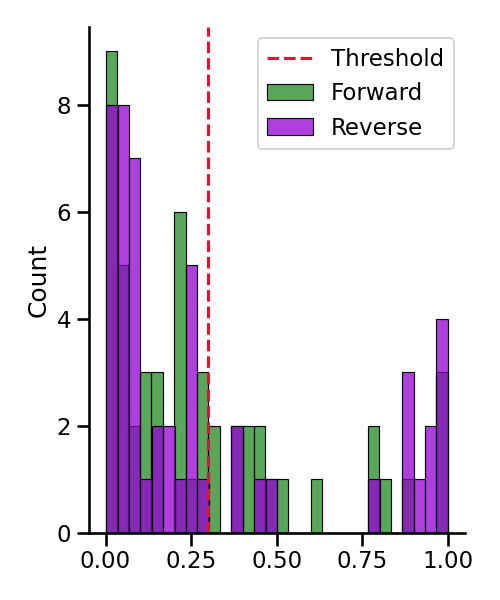

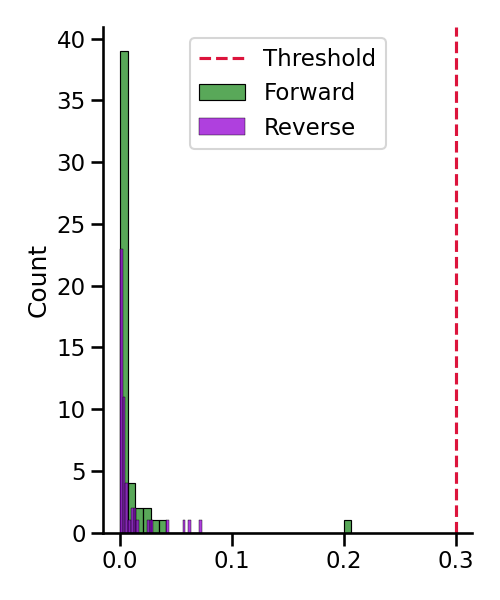

[ 4 11 13 22 30 34 49]
[ 2  7 12 14 20 26 31 37 42 43 50]


In [13]:
# plot the distribution of transitions probabilities for all the non-zero transitions
colors = ['forestgreen', 'darkviolet']
for i in range(3):
    plt.figure(figsize=(5, 6))
    for j in range(2):
        sns.histplot(non_zero_transitions[i * 2 + j, :], bins=30, kde=False, color = colors[j])
    
    plt.axvline(x=0.3, linestyle='--', color = 'crimson')
    plt.tight_layout()
    sns.despine()
    plt.legend([ 'Threshold', 'Forward', 'Reverse'])
    plt.show()


# get seq boundaries as where transition probs are < 0.3
seq_bounds_forward = np.where(non_zero_transitions[0, :] < 0.3)[0] + 1
seq_bounds_reverse = np.where(non_zero_transitions[1, :] < 0.3)[0] + 1

print(seq_bounds_forward)
print(seq_bounds_reverse)


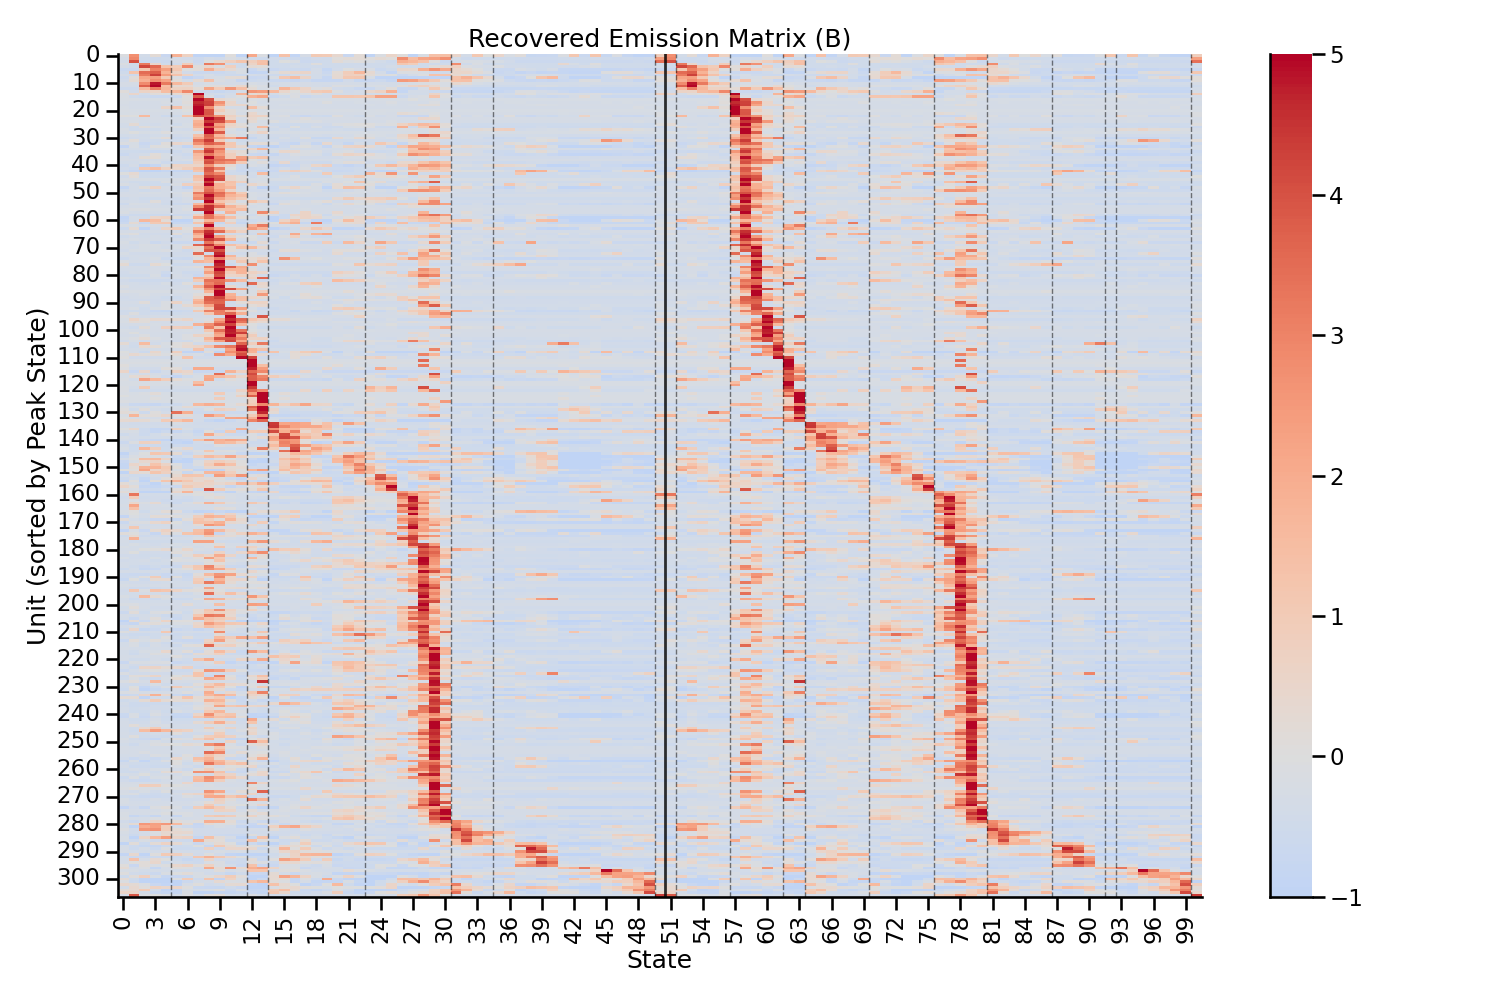

In [14]:


plt.figure(figsize=(15, 10))
sns.heatmap(B_sorted_normalized.T, cmap="coolwarm", center=0, vmin = -1, vmax = 5)

# draw verical lines at the sequence boundaries
for bound in seq_bounds_forward:
    plt.axvline(x=bound + 1, color='k', linestyle='--', linewidth=1, alpha = 0.5)

for bound in seq_bounds_reverse:
    plt.axvline(x=bound + columns, color='k', linestyle='--', linewidth=1, alpha = 0.5)

# plot vertical line between teh forward and reverse sequences
plt.axvline(x=(B.shape[0] // 2) + 1, color='k', linestyle='-', linewidth=2, alpha = 0.8)


plt.title("Recovered Emission Matrix (B)")
plt.xlabel("State")
plt.ylabel("Unit (sorted by Peak State)")
plt.tight_layout()
sns.despine()
plt.show()




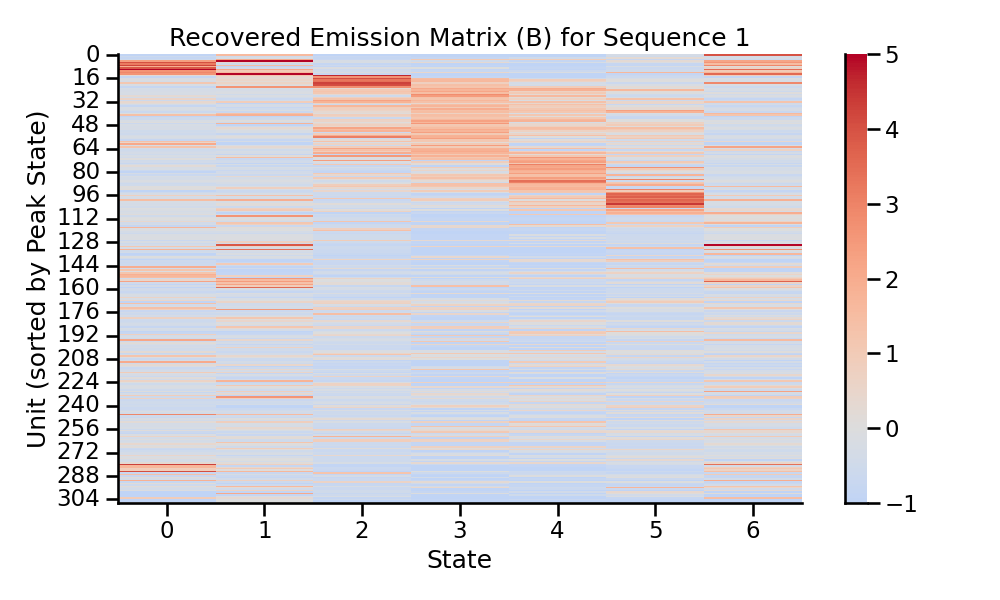

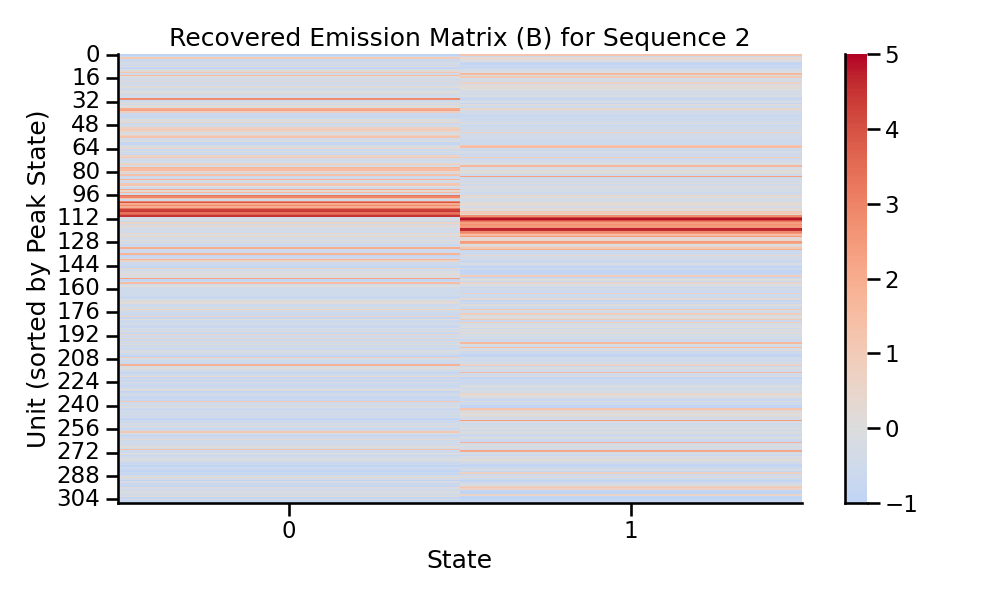

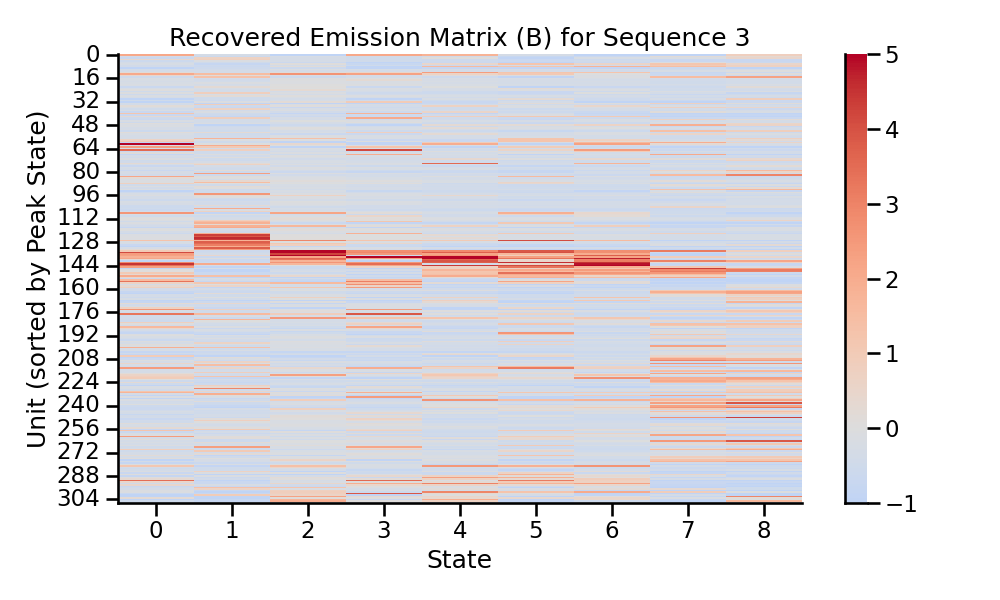

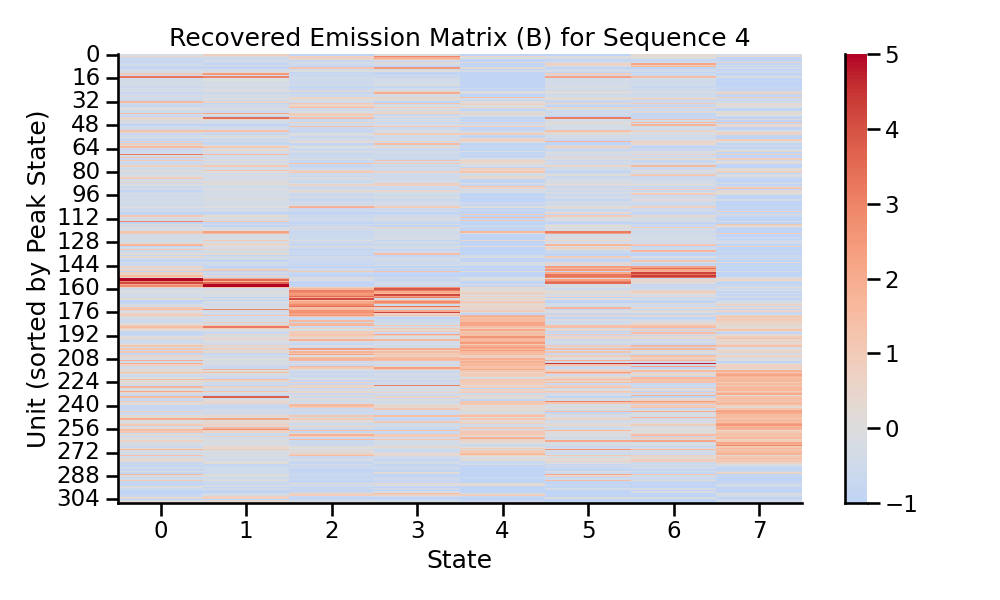

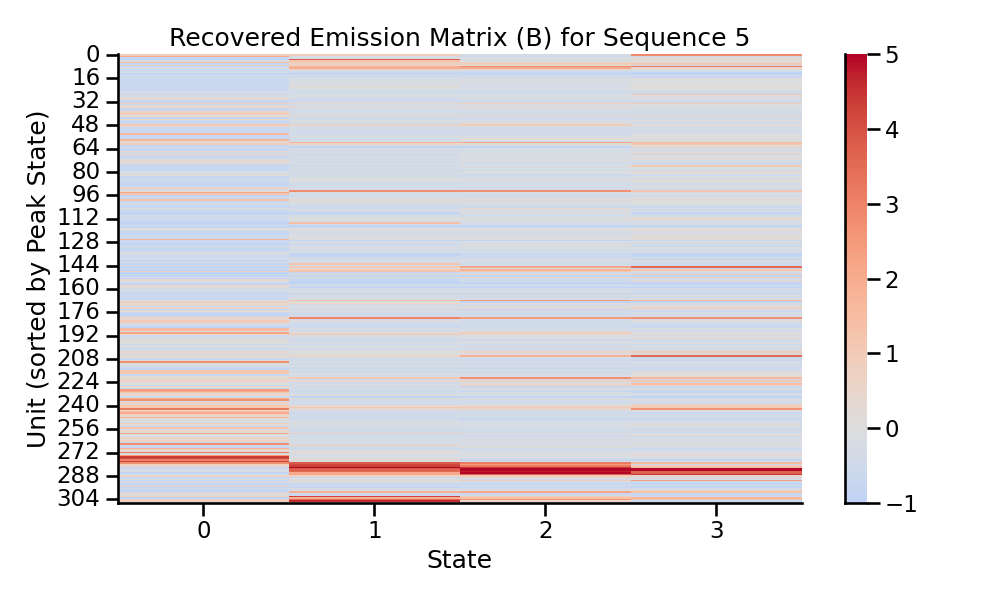

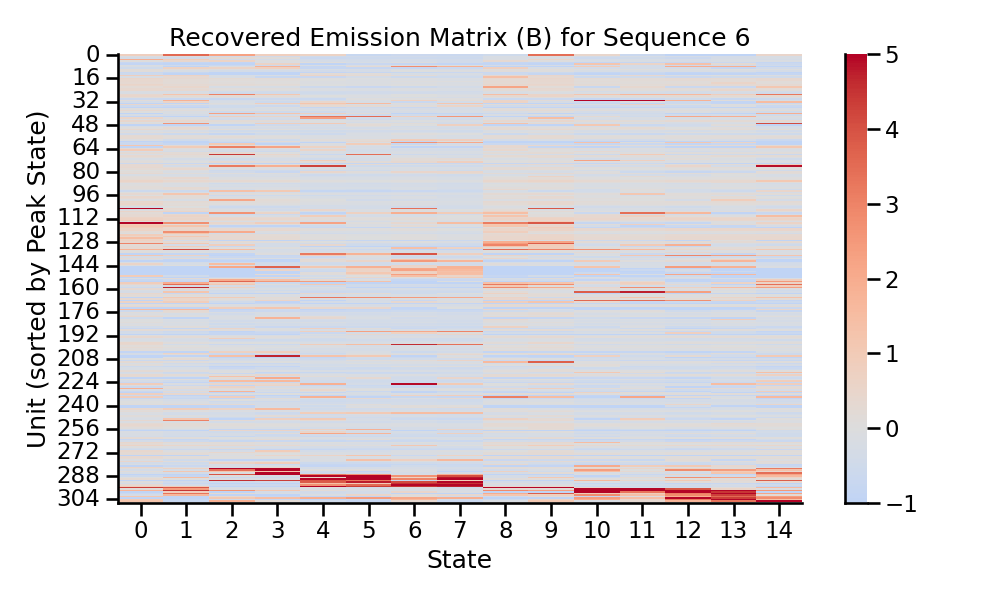

In [15]:
# for each sequence (latent states between sequence_bounds), show the emissions matrix with the neurons sorted just to those latent states
for i, (start, end) in enumerate(zip(seq_bounds_forward[:-1], seq_bounds_forward[1:])):

    # resort the neurons to just the latent states between the sequence boundaries
    B_subset = stats.zscore(B_sorted_normalized[start:end], axis=1)
    sort_order = np.argsort(np.argmax(B_subset, axis=1))


    plt.figure(figsize=(10, 6))
    sns.heatmap(B_subset[sort_order].T, cmap="coolwarm", center=0, vmin=-1, vmax=5)
    plt.title(f"Recovered Emission Matrix (B) for Sequence {i+1}")
    plt.xlabel("State")
    plt.ylabel("Unit (sorted by Peak State)")
    plt.tight_layout()
    sns.despine()
    plt.show()


# load in the data and run inference on the best fit parameters to get the most likely state sequence and compare to the true state sequence if available.


Tracking keys: ('timestamps', 'frameCount', 'position', 'orientation', 'errorPerMarker', 'substructnames', 'rotation_type', 'acquisition_system', 'description')
Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y.


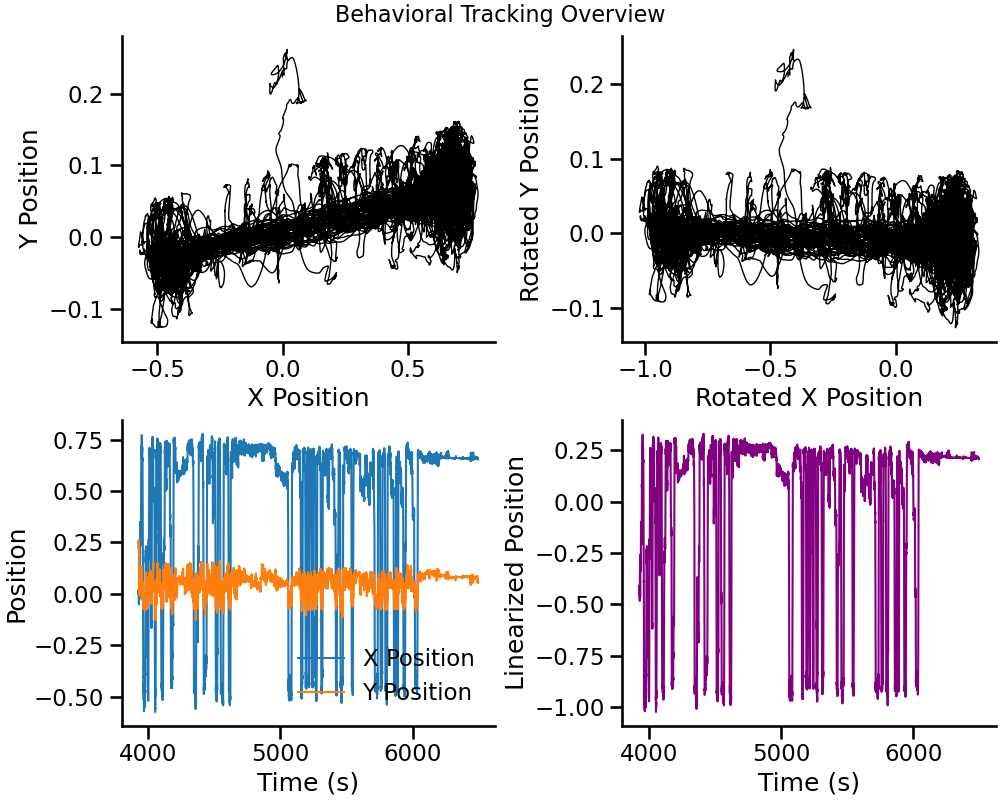

In [16]:

from scipy.io import loadmat
from sklearn.decomposition import PCA


tracking_file = '/mnt/home/srafilson/ceph/Bilat_R02_20251106/Bilat_R02_20251106_imec0.tracking.behavior.mat'
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']
print("Tracking keys:", tracking.dtype.names)

tracking_timestamps = tracking['timestamps'].item() # these are timestamps in seconds which are aligned to the raw spike times
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())
print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y.')

# do PCA to linearize the position
positions = np.vstack((x, y)).T
positions_fit_pca = positions[500:-500]

pca = PCA(n_components=1)

# fit PCA only on trimmed data
pca.fit(positions_fit_pca)

# project ALL positions onto the learned axis
linearized_position = pca.transform(positions).flatten()

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]





fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0,0].plot(x, y, color="black", linewidth=1)
axs[0,0].set_xlabel("X Position")
axs[0,0].set_ylabel("Y Position")



# --- Bottom: Position over time ---
axs[1,0].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1,0].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Position")
axs[1,0].legend(frameon=False)

# --- Optional: linearized position over time
axs[1,1].plot(tracking_timestamps, linearized_position, color="purple", linewidth=1.5)
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Linearized Position")


# rotate the XY trajectory by the angle of the first principal component for better visualization
angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])

rotation_matrix = np.array([
    [np.cos(-angle), -np.sin(-angle)],
    [np.sin(-angle),  np.cos(-angle)]
])

rotated_positions = (positions - positions.mean(axis=0)) @ rotation_matrix.T
axs[0,1].plot(rotated_positions[:,0], rotated_positions[:,1], color="black", linewidth=1)
axs[0,1].set_xlabel("Rotated X Position")
axs[0,1].set_ylabel("Rotated Y Position")



sns.despine()
fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()



In [17]:
from custom_hmm import PoissonHMM

data_path = '/mnt/home/srafilson/code/sequences/data/maze_clipped_spike_counts_Bilat_R02_20251106.npz'
data = np.load(data_path, allow_pickle=True)



print(data.files)


# get the observations and true states from the data
observations = data["observations"]
print(f"Observations shape: {observations.shape}")
if "states" in data:
    true_states = data["states"]
else:
    true_states = None

if "time_bins" in data:
    time_bins = data["time_bins"]
else:
    time_bins = None



['observations', 'time_bins']
Observations shape: (130600, 307)


In [18]:
# resample the linearized position so that each position corresponds to a time bin in the observations
if time_bins is not None:
    # get the start and end time of the observations
    start_time = time_bins[0]
    end_time = time_bins[-1]

    # resample the linearized position to match the number of time bins in the observations
    linearized_position_resampled = np.interp(time_bins, tracking_timestamps, linearized_position)

    print(f"Resampled linearized position to match observations: {linearized_position_resampled.shape} vs {observations.shape[0]} time bins.")

    # bin the linearized position into discrete states (e.g., 10 bins)
    n_bins = 50
    linearized_position_binned = np.digitize(linearized_position_resampled, bins=np.linspace(np.min(linearized_position_resampled), np.max(linearized_position_resampled), n_bins))
else:
    linearized_position_resampled = None
    linearized_position_binned = None
    print("No time_bins found in the data. Skipping resampling of linearized position.")

Resampled linearized position to match observations: (130600,) vs 130600 time bins.


In [19]:


model = PoissonHMM(
    A=A,
    B=B,
    pi=pi
)

model.set_observations(observations)

states = model.viterbi()




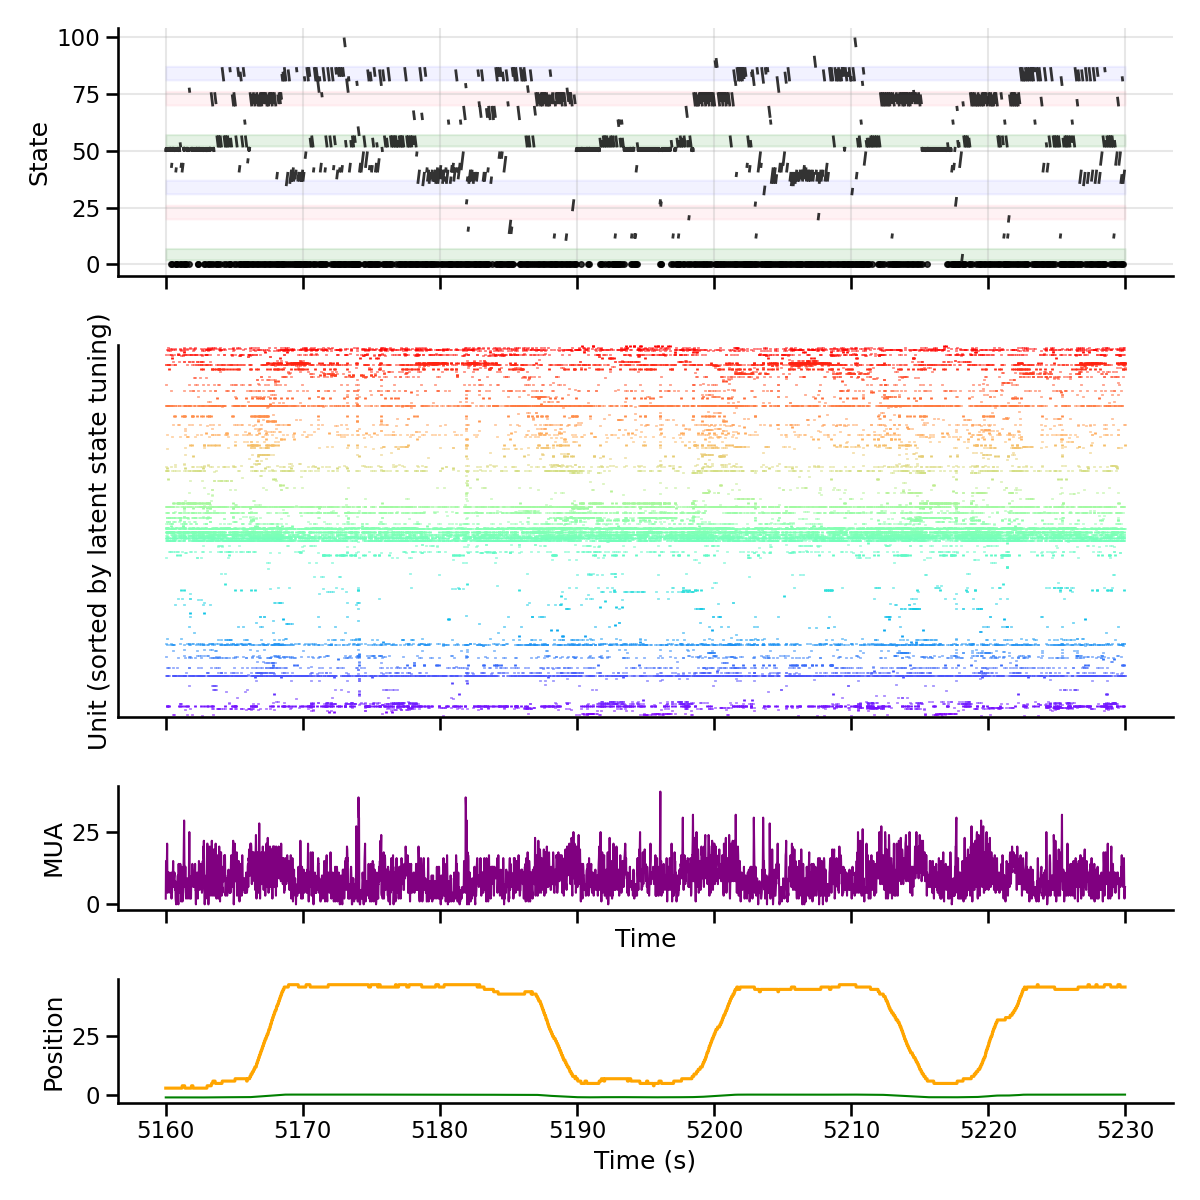

In [25]:
%matplotlib widget

start_time_s = 5160
end_time_s = 5230

start_time = np.searchsorted(time_bins, start_time_s)
end_time = np.searchsorted(time_bins, end_time_s)

t = time_bins[start_time:end_time]

# MUA should sum across units for each time bin
mua = np.sum(observations, axis=1)



obs_sorted = observations[start_time:end_time][:, state_order]

fig, axs = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 3, 1, 1]}
)

# fill between states 10 and 20
axs[0].fill_between(
    t,
    70,
    76,
    color="pink",
    alpha=0.2
)

# fill between states 10 and 20
axs[0].fill_between(
    t,
    20,
    26,
    color="pink",
    alpha=0.2
)


# fill between states 10 and 20
axs[0].fill_between(
    t,
    2,
    7,
    color="green",
    alpha=0.1
)

# fill between states 10 and 20
axs[0].fill_between(
    t,
    52,
    57,
    color="green",
    alpha=0.1
)


# fill between states 10 and 20
axs[0].fill_between(
    t,
    31,
    37,
    color="blue",
    alpha=0.05
)

# fill between states 10 and 20
axs[0].fill_between(
    t,
    81,
    87,
    color="blue",
    alpha=0.05
)








# inferred state sequence, avoiding lines through base state
state_seq = states[start_time:end_time]
base_state = 0


axs[0].set_ylabel("State")
axs[0].grid(alpha=0.3)

# plot non-base states, broken wherever base state occurs
non_base = np.where(state_seq != base_state, state_seq, np.nan)

axs[0].plot(
    t,
    non_base,
    linewidth=2,
    alpha=0.8,
    color="black"
)

# plot base-state runs separately
is_base = state_seq == base_state

# find contiguous base-state runs
base_idx = np.where(is_base)[0]

if len(base_idx) > 0:
    split_points = np.where(np.diff(base_idx) > 1)[0] + 1
    base_runs = np.split(base_idx, split_points)

    for run in base_runs:
        if len(run) == 1:
            axs[0].plot(
                t[run],
                state_seq[run],
                marker="o",
                linestyle="None",
                color="k",
                markersize=4,
                alpha=0.8
            )
        else:
            axs[0].plot(
                t[run],
                state_seq[run],
                linewidth=2,
                color="k",
                alpha=0.8
            )



# spike raster: one tick for any count >= 1
n_units = obs_sorted.shape[1]

spike_times_by_unit = [
    t[obs_sorted[:, unit_idx] >= 1]
    for unit_idx in range(n_units)
]

colors = plt.cm.rainbow(np.linspace(0, 1, n_units))

axs[1].eventplot(
    spike_times_by_unit,
    orientation="horizontal",
    colors=colors,
    lineoffsets=np.arange(n_units),
    linelengths=1,
    linewidths=2
)


axs[1].set_ylabel("Unit (sorted by latent state tuning)")
axs[1].set_ylim(-1, n_units)
axs[1].set_yticks([])

# MUA
axs[2].plot(
    t,
    mua[start_time:end_time],
    label="MUA",
    color="purple",
    linewidth=1.5
)

axs[2].set_xlabel("Time")
axs[2].set_ylabel("MUA")


# plot the linearized position over time
axs[3].plot(
    t,
    linearized_position_resampled[start_time:end_time],
    label="Linearized Position",


    color="green",
    linewidth=1.5
)

axs[3].plot(
    t,
    linearized_position_binned[start_time:end_time],
    label="Binned Linearized Position",
    color="orange",
)

axs[3].set_xlabel("Time (s)")
axs[3].set_ylabel("Position")

sns.despine()
plt.tight_layout()
plt.show()

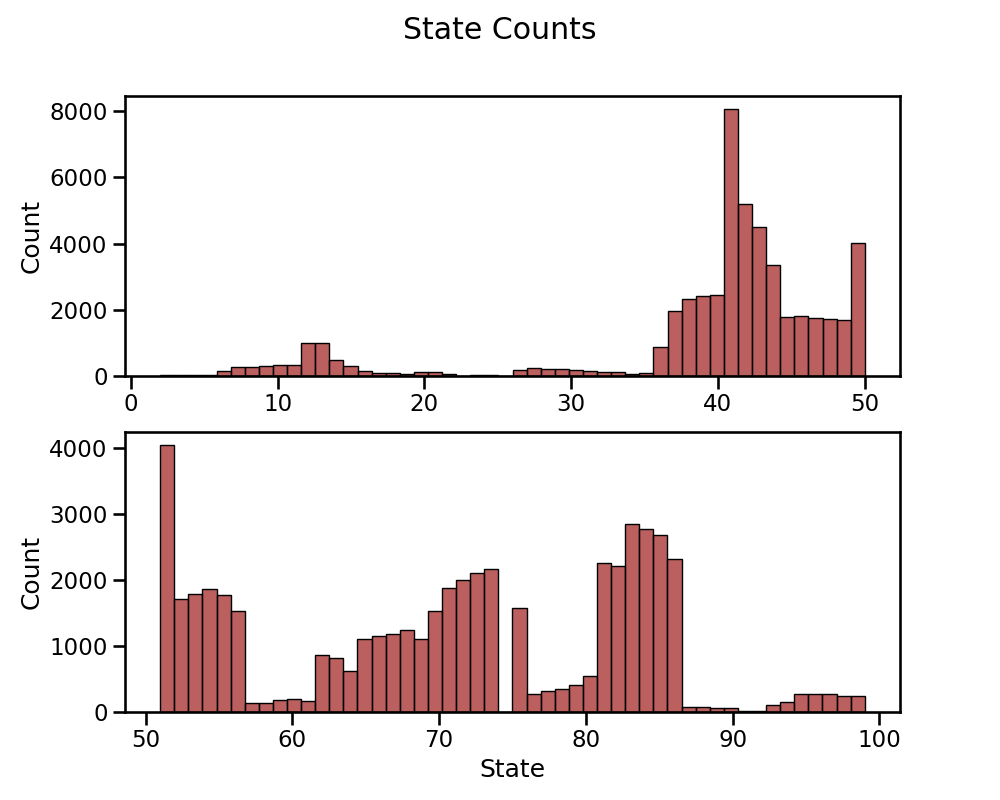

In [30]:
# get the counts for how hoften in each state
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
sns.histplot(states[(states != 0) & (states <= 50)], bins=50, ax=axs[0], color = 'brown')
axs[0].set_ylabel('Count')

sns.histplot(states[states > 50], bins=50, ax=axs[1], color = 'brown')
axs[1].set_xlabel('State')
axs[1].set_ylabel('Count')

plt.suptitle('State Counts')

plt.show()

In [31]:
from tqdm import tqdm

# compute the place field (spatial tuning) of each latent state
place_fields = np.zeros((A.shape[0], linearized_position_binned.max() + 1))

for state in tqdm(range(A.shape[0])):
    # get the time bins where the state is active
    state_active = states == state

    # get the linearized position bins for those time bins
    position_bins = linearized_position_binned[state_active]

    # compute the histogram of position bins for this state
    place_fields[state], _ = np.histogram(position_bins, bins=np.arange(linearized_position_binned.max() + 2), density=True)


print(place_fields.shape)

# smooth the place fields with a Gaussian filter
from scipy.ndimage import gaussian_filter1d

place_fields_smoothed = gaussian_filter1d(place_fields, sigma=3, axis=1)
    

        


        

  0%|          | 0/101 [00:00<?, ?it/s]/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
100%|██████████| 101/101 [00:00<00:00, 4257.92it/s]

(101, 51)


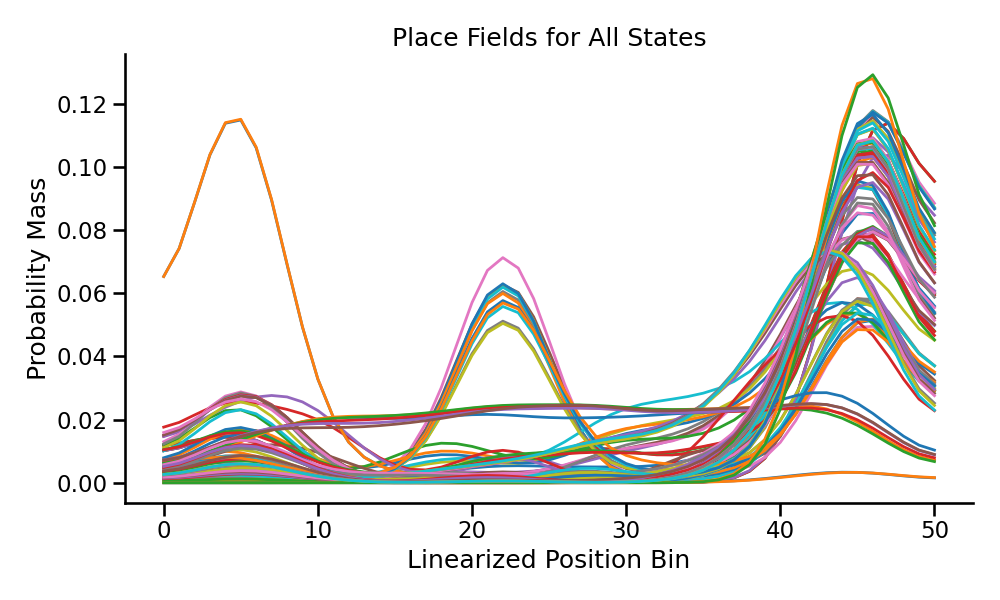

In [32]:
# plot all the place fields as line plots
plt.figure(figsize=(10, 6))
for state in range(place_fields.shape[0]):
    plt.plot(place_fields_smoothed[state], label=f"State {state}", linewidth=2)
plt.title("Place Fields for All States")
plt.xlabel("Linearized Position Bin")
plt.ylabel("Probability Mass")
plt.tight_layout()
sns.despine()
plt.show()

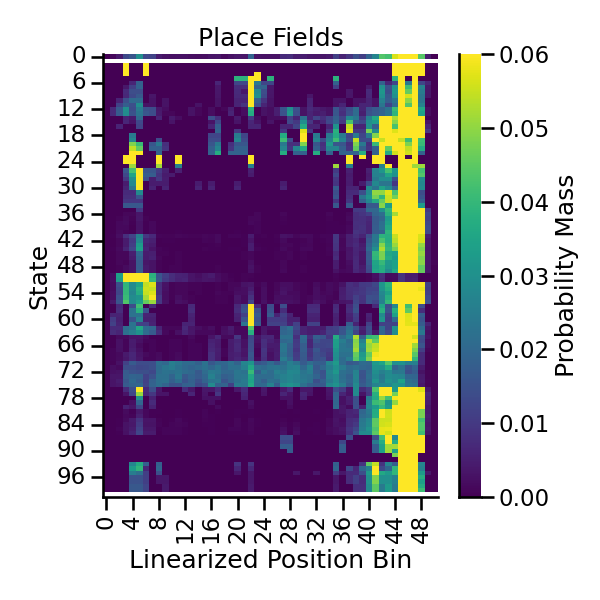

In [35]:
# plot the un sorted place fields as a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(place_fields, cmap="viridis", cbar_kws={'label': 'Probability Mass'}, vmin=0, vmax = 0.06)
plt.title("Place Fields")
plt.xlabel("Linearized Position Bin")
plt.ylabel("State")
plt.tight_layout()
sns.despine()
plt.show()




/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


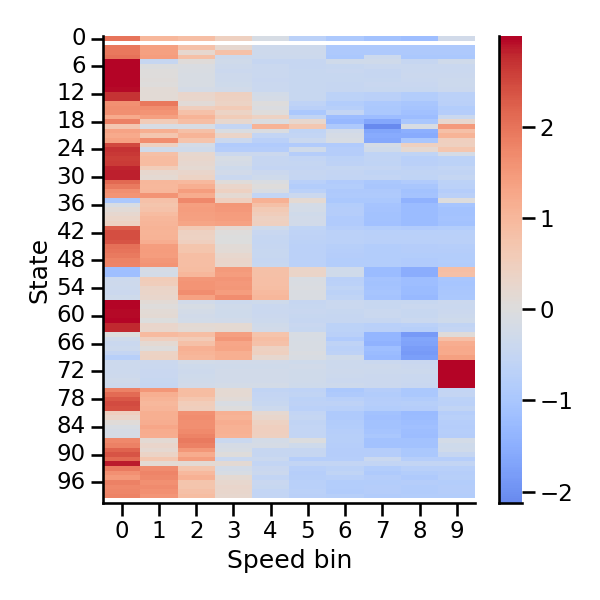

In [40]:
speed = np.abs(np.gradient(linearized_position_resampled))
# smooth the speed signal using a Gaussian filter
speed = gaussian_filter1d(speed, sigma=10)

speed_bins = np.linspace(0, np.percentile(speed, 90), 10)
speed_binned = np.digitize(speed, speed_bins) - 1


# get the speed tuning for each state
speed_tuning = np.zeros((A.shape[0], speed_binned.max() + 1))
for state in range(A.shape[0]):
    state_active = states == state

    speed_bins = speed_binned[state_active]

    speed_tuning[state], _ = np.histogram(speed_bins, bins=np.arange(speed_binned.max() + 2), density=True)


# plot the speed tuning heatmap 
plt.figure(figsize=(6, 6))
sns.heatmap(stats.zscore(speed_tuning, axis=1), cmap='coolwarm', center=0)
plt.xlabel('Speed bin')
plt.ylabel('State')
plt.tight_layout()
sns.despine()
plt.show()



In [72]:
print(observations.shape, time_bins.shape, linearized_position_binned.shape)

(130600, 307) (130600,) (130600,)


In [41]:
# loading the data dicts to get the anatomical tuning (shank and probe numbers)
data_dict_path = '/mnt/home/srafilson/code/sequences/data/data_dicts_all_neurons.npz'
data_dict = np.load(data_dict_path, allow_pickle=True)

PROBES = [2, 3]  # list of probe numbers to include in the analysis

probe_shank_order = [(2,4), (2,3), (2,2), (2,1), (3,1), (3,2), (3,3), (3,4)] # this list is sorted by probe and shank number from anterior to posterior (septal-> temporal), so that we can sort the units in the spike count matrix according to anotmical position


# concatenate spike count matrices and time bins across probes for the decoding analysis keeping on the valid units
all_spike_counts = []
all_time_bins = []
shank_IDs = []
probe_IDs = []
for probe in PROBES:
    if f'probe{probe}' in data_dict:
        probe_data = data_dict[f'probe{probe}'].item()
        if 'spike_count_matrix' in probe_data and 'time_bins' in probe_data:
            valid_units = probe_data['valid_units']
            all_spike_counts.append(probe_data['spike_count_matrix'][valid_units, :]) # only keep the valid units for the decoding analysis
            all_time_bins.append(probe_data['time_bins'])
            # get the shank IDs for the valid units
            shank_IDs.append(probe_data['shankID'][valid_units])
            probe_IDs.append(np.full(np.sum(valid_units), probe))
        else:
            print(f"Probe {probe}: Missing spike count matrix or time bins for concatenation.")
    else:
        print(f"Probe {probe}: Missing data in the loaded dictionary.")

spike_count_matrix = np.concatenate(all_spike_counts, axis=0) if all_spike_counts else np.array([]) # shape: (total_units_across_probes, n_time_bins)
time_bins = all_time_bins[0] if all_time_bins else np.array([])
shank_IDs = np.concatenate(shank_IDs, axis=0) if shank_IDs else np.array([])
probe_IDs = np.concatenate(probe_IDs, axis=0) if probe_IDs else np.array([])



In [42]:
anatomical_order = []


for unit_idx in range(spike_count_matrix.shape[0]):
    probe = probe_IDs[unit_idx]
    shank = shank_IDs[unit_idx]
    anatomical_order.append(probe_shank_order.index((probe, shank)))

anatomical_order = np.array(anatomical_order)


n_anatomical_positions = np.unique(anatomical_order).size






In [43]:
# Reorder observation columns (neurons) according to the state that emits each observation with the highest probability.
state_order = np.argsort(np.argmax(B, axis=0))
B_sorted = B[:, state_order]

# normalize so area under each column is 1
B_sorted_normalized = stats.zscore(B_sorted, axis=0)

In [44]:
print(anatomical_order)
anatomical_sort_order = np.argsort(anatomical_order)
print(anatomical_sort_order)

[2 3 3 2 2 0 0 3 2 0 0 0 3 2 2 1 0 0 0 0 3 3 3 2 1 0 0 3 1 0 0 0 3 3 2 2 1
 0 0 0 0 3 3 3 3 3 3 3 3 2 2 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 3 3 2 2 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0
 0 0 0 0 0 0 0 0 0 0 0 3 3 3 2 2 2 2 2 2 2 1 1 1 1 0 0 0 0 0 0 2 2 2 2 2 2
 1 1 0 0 2 2 2 2 2 1 1 1 1 0 3 3 2 2 0 0 0 3 0 0 0 2 0 3 0 0 3 6 5 6 5 6 6
 5 5 6 6 6 6 6 6 6 6 6 6 6 6 5 6 6 6 6 6 6 6 5 5 5 6 6 6 6 6 6 6 6 6 6 5 5
 5 5 5 5 6 6 6 6 6 6 4 5 5 5 6 6 6 4 5 5 5 5 5 5 4 5 5 4 5 5 5 5 5 6 5 5 5
 5 5 5 5 5 5 5 5 4 4 4 5 5 5 5 5 4 5 5 5 5 5 5 5 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 6 4 4 6 4 4 4 4 4]
[  6   5  10   9  11  18  17  16  55  54  53  52  51  86  89  88  80  81
  82  83  84  85  79  78  72  73  74  75  76  77  71  70  87 138 141 113
 112 117 118 119 120 121 114 140 137 136 151 150 139 110 109 115 116 111
  26  25 168 170 171 172 174 166 167 161 176 177  19  31  29  30  37  40
  38  39  24  28  36 160 158  15 132 133 157 159 149 148 135 134  96 142
 143 127 12

In [45]:
# average all the columns of B with the same anatomical_order value
B_anatomical_averaged = np.zeros((B.shape[0], len(np.unique(anatomical_order))))
for i, val in enumerate(np.unique(anatomical_order)):
    B_anatomical_averaged[:, i] = B[:, anatomical_order == val].mean(axis=1)

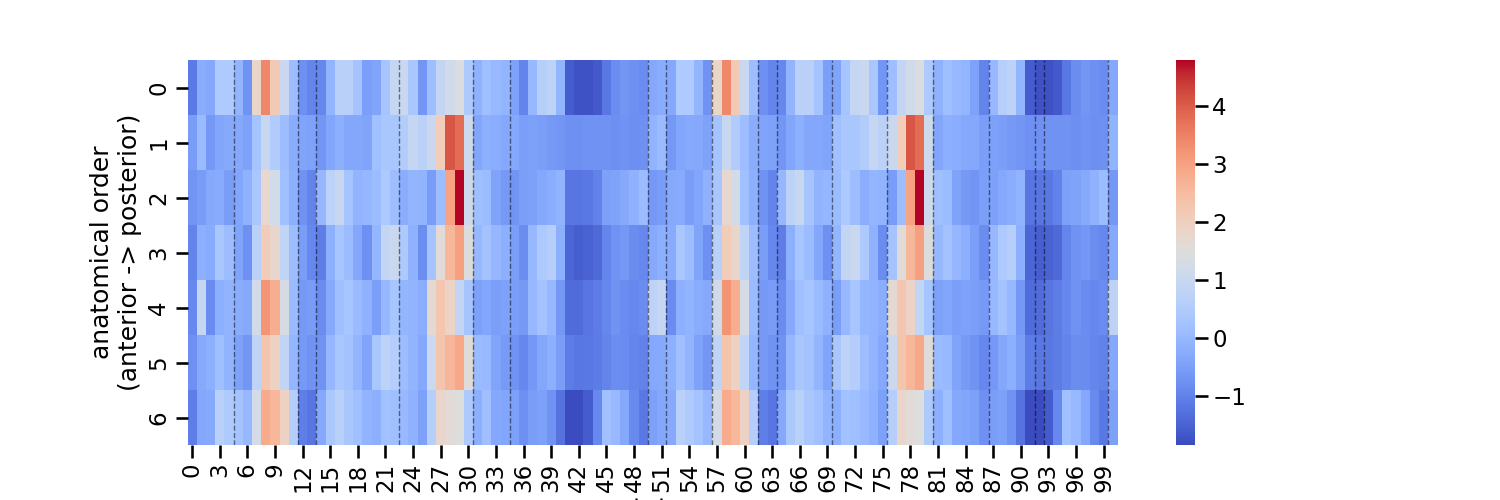

In [46]:
# plot the averaged emissions matrix by anatomical order
B_anatomical_averaged_normalized = stats.zscore(B_anatomical_averaged, axis=0)
plt.figure(figsize=(15, 5))
sns.heatmap(B_anatomical_averaged_normalized.T, cmap ='coolwarm')

# draw verical lines at the sequence boundaries
for bound in seq_bounds_forward:
    plt.axvline(x=bound + 1, color='k', linestyle='--', linewidth=1, alpha = 0.5)

for bound in seq_bounds_reverse:
    plt.axvline(x=bound + columns, color='k', linestyle='--', linewidth=1, alpha = 0.5)


plt.xlabel('state')
plt.ylabel('anatomical order\n(anterior -> posterior)')
plt.show()

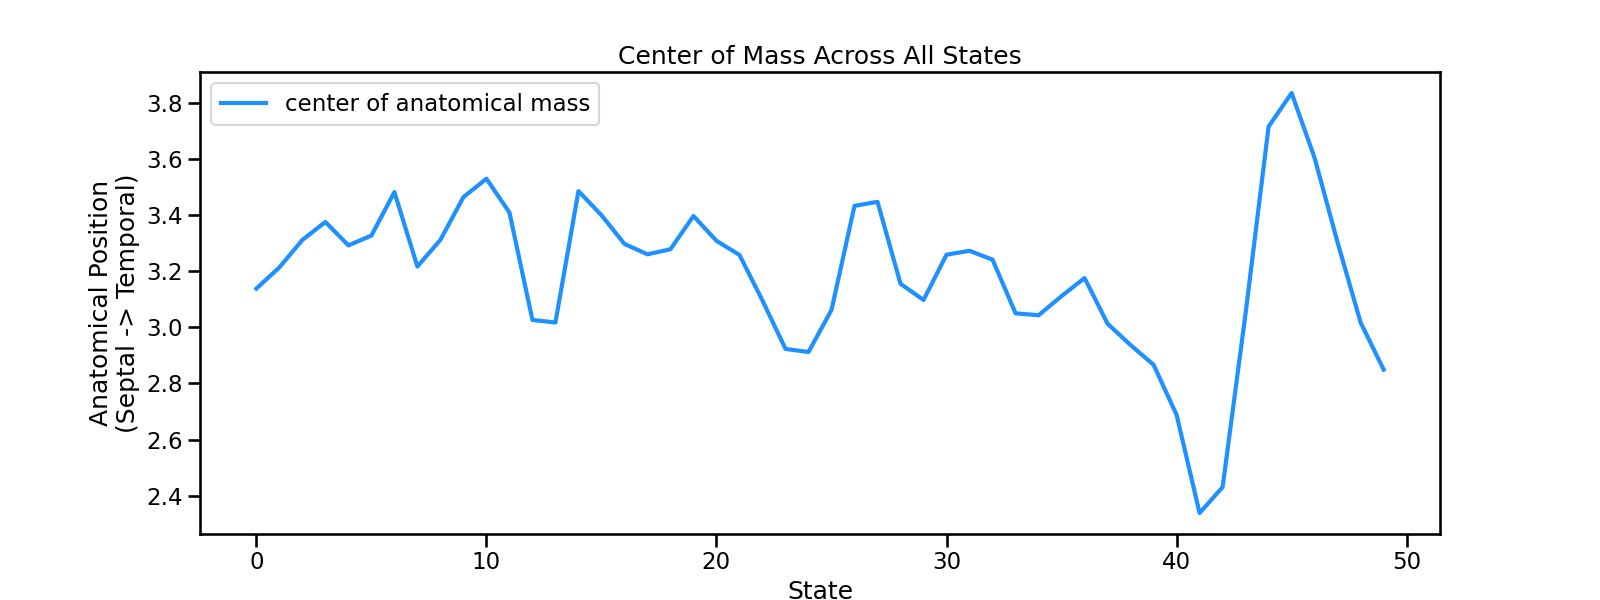

In [53]:
from scipy.stats import pearsonr



# average all the columns of B with the same anatomical_order value
B_anatomical_averaged = np.zeros((B.shape[0], len(np.unique(anatomical_order))))
for i, val in enumerate(np.unique(anatomical_order)):
    B_anatomical_averaged[:, i] = B[:, anatomical_order == val].mean(axis=1)

# make one long plot showing the center of mass across all the states
com = []
nStates = B_anatomical_averaged.shape[0] // 2 
for state in range(nStates):
    state_distribution = B_anatomical_averaged[state, :]
    state_distribution = state_distribution / np.sum(state_distribution)
    center_of_mass_position = np.sum(np.arange(len(state_distribution)) * state_distribution) / np.sum(state_distribution)
    com.append(center_of_mass_position)
com = np.array(com)
plt.figure(figsize=(16, 6))
plt.plot(range(len(com)), com, label="center of anatomical mass", linewidth=3, color = 'dodgerblue')
# plot vertical lines for sequence transitions

plt.title("Center of Mass Across All States")
plt.xlabel("State")
plt.ylabel("Anatomical Position\n(Septal -> Temporal)")
plt.legend()
plt.show()


 


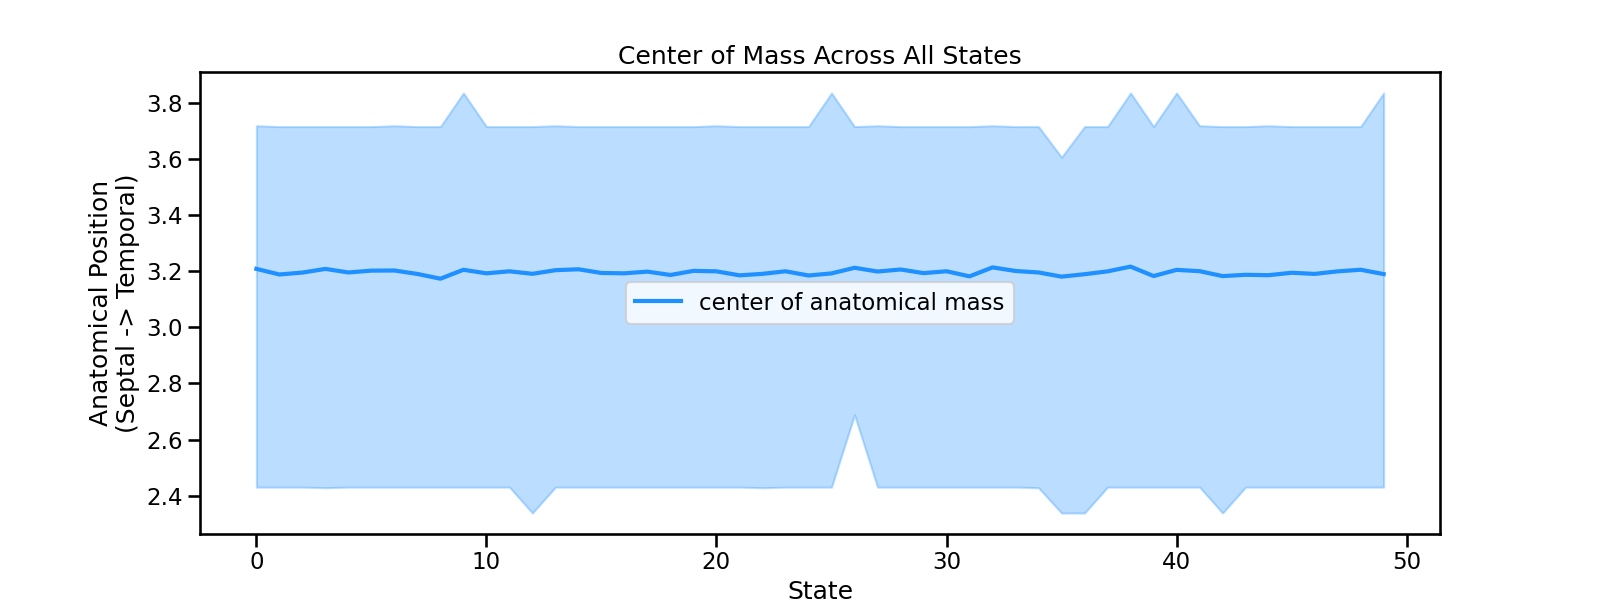

In [ ]:
#### BOOTSTRAP


from scipy.stats import pearsonr

Niters = 1000
all_com = []

# subsample for bootstrap confidence intervals
for iter in range(Niters):

    samples = np.random.choice(B.shape[0], size=B.shape[0], replace=True)

    # average all the columns of B with the same anatomical_order value
    B_anatomical_averaged = np.zeros((len(samples), len(np.unique(anatomical_order))))
    for i, val in enumerate(np.unique(anatomical_order)):
        B_anatomical_averaged[:, i] = B[samples, :][:, anatomical_order == val].mean(axis=1)

    # make one long plot showing the center of mass across all the states
    com = []
    nStates = B_anatomical_averaged.shape[0] // 2 
    for state in range(nStates):
        state_distribution = B_anatomical_averaged[state, :]
        state_distribution = state_distribution / np.sum(state_distribution)
        center_of_mass_position = np.sum(np.arange(len(state_distribution)) * state_distribution) / np.sum(state_distribution)
        com.append(center_of_mass_position)
    com = np.array(com)
    all_com.append(com)


mean_com = np.mean(all_com, axis=0)
lower_com = np.percentile(all_com, 2.5, axis=0)
upper_com = np.percentile(all_com, 97.5, axis=0)

plt.figure(figsize=(16, 6))
plt.plot(range(len(mean_com)), mean_com, label="center of anatomical mass", linewidth=3, color = 'dodgerblue')
plt.fill_between(range(len(mean_com)), lower_com, upper_com, color='dodgerblue', alpha=0.3)
# plot vertical lines for sequence transitions

plt.title("Center of Mass Across All States")
plt.xlabel("State")
plt.ylabel("Anatomical Position\n(Septal -> Temporal)")
plt.legend()
plt.show()


Current interval: (0, 4)
(4, 7)


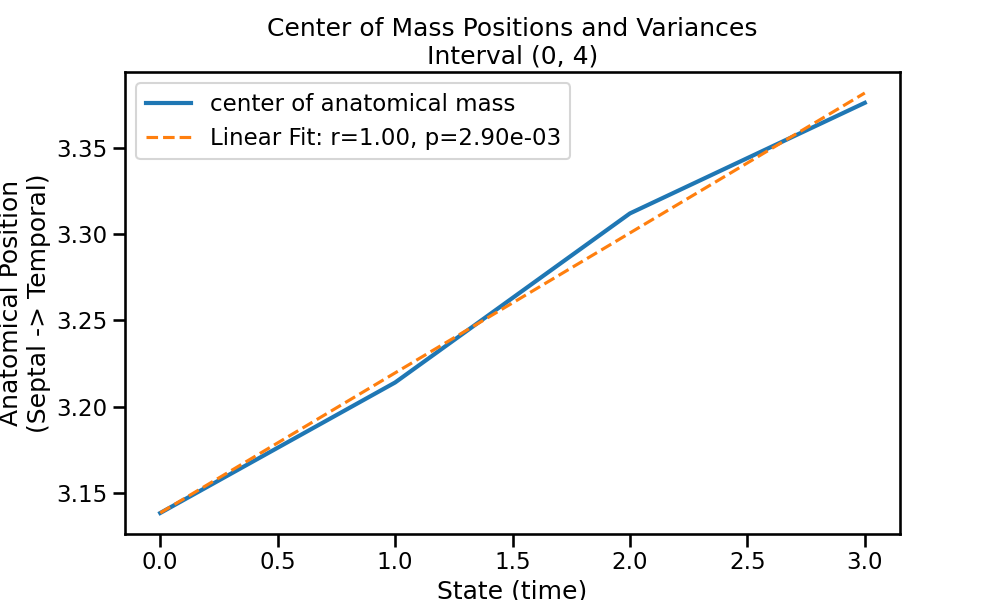

Current interval: (4, 11)
(7, 7)


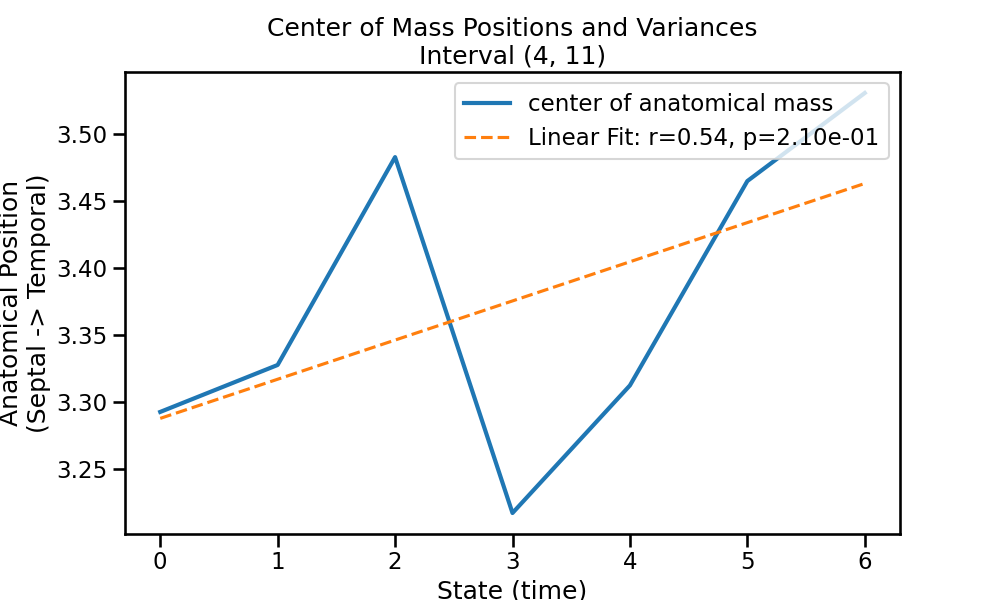

Current interval: (11, 13)
(2, 7)


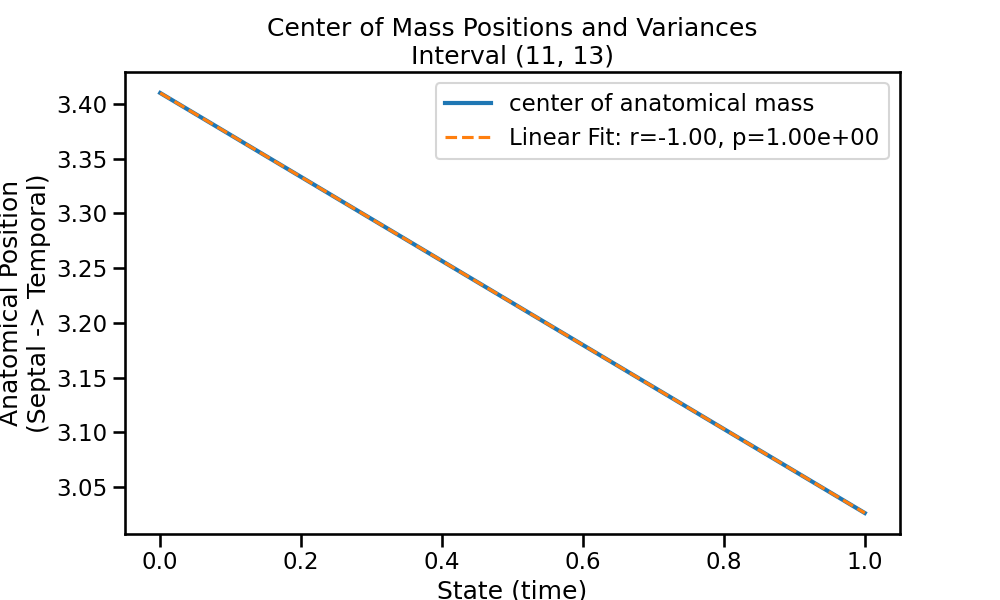

Current interval: (13, 22)
(9, 7)


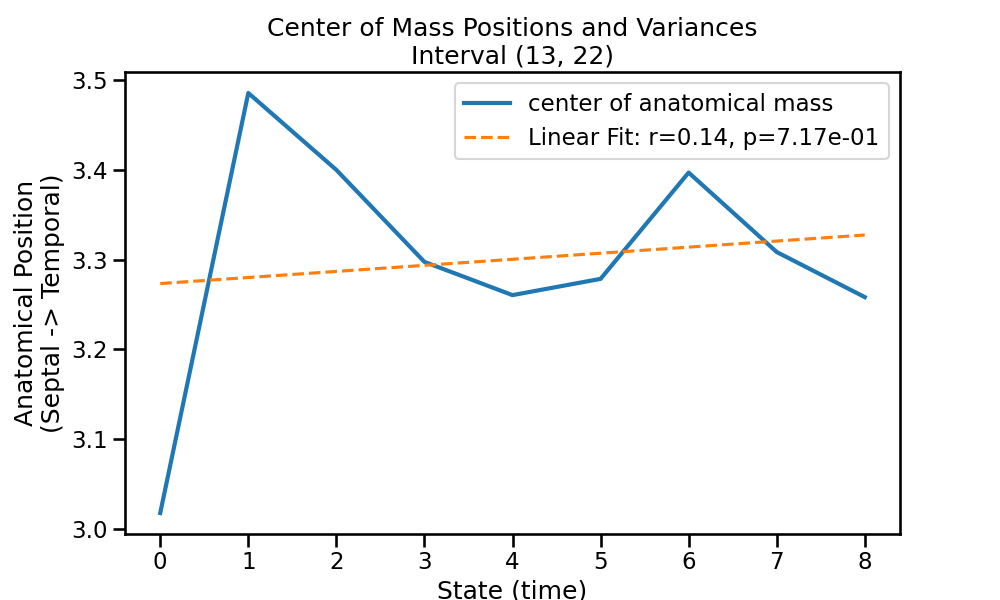

Current interval: (22, 30)
(8, 7)


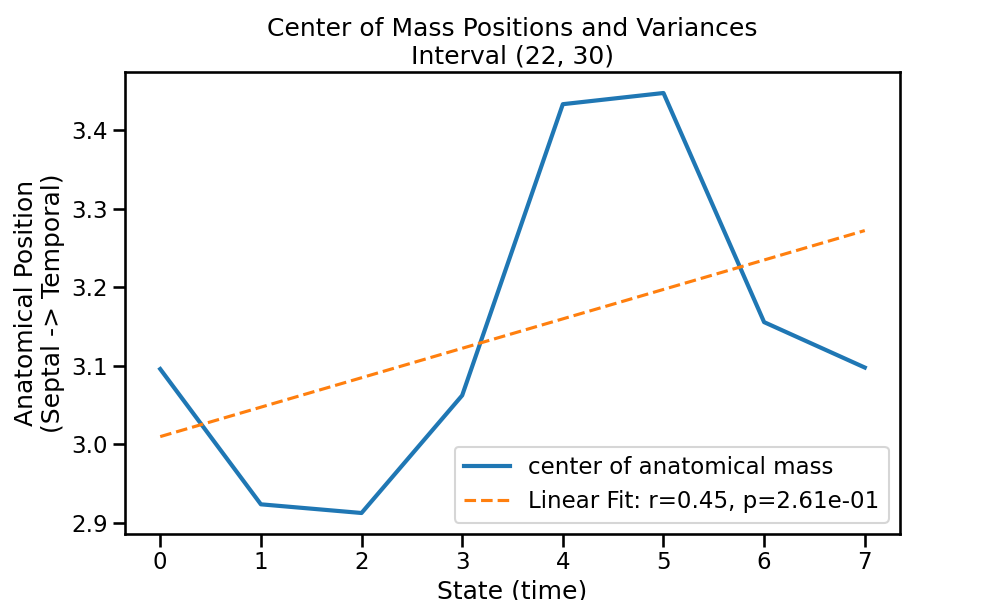

Current interval: (30, 34)
(4, 7)


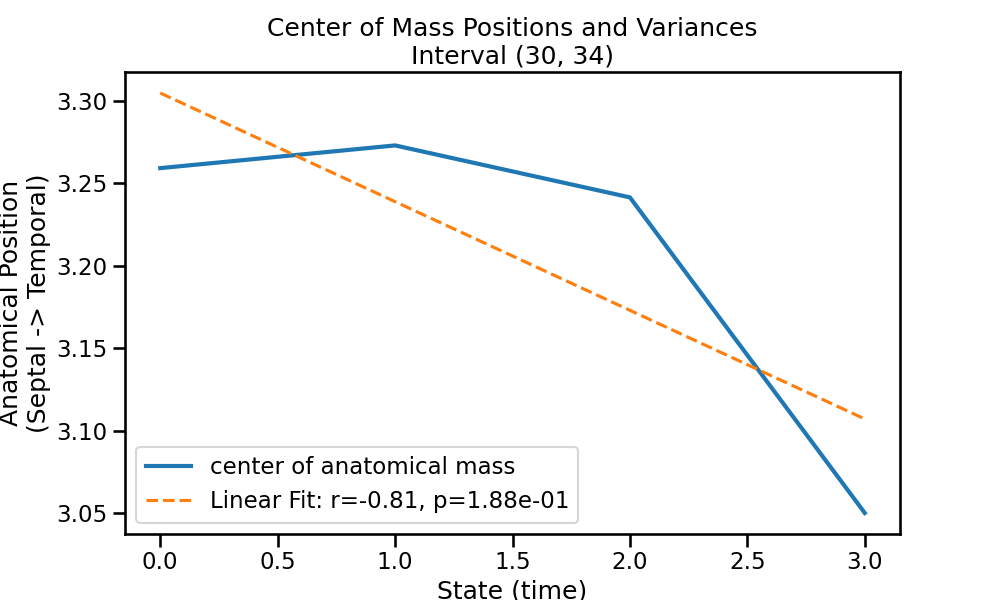

In [80]:

for i, bound in enumerate([0] + list(seq_bounds_forward[:-2])):


    seq_bound = seq_bounds_forward[i]
    
    current_interval = (int(bound), int(seq_bound))
    print(f"Current interval: {current_interval}")

    # get the anatomical position at the median of the distribution for each state within the current interval
    current_emissions_matrix = B_anatomical_averaged[current_interval[0]:current_interval[1], :]
    print(current_emissions_matrix.shape)


    com = []
    median_positions = []
    rmse = []
    for state in range(current_emissions_matrix.shape[0]):
        state_distribution = current_emissions_matrix[state, :]

        #normalize so valid pmf
        state_distribution = state_distribution / np.sum(state_distribution)

        center_of_mass_position = np.sum(np.arange(len(state_distribution)) * state_distribution) / np.sum(state_distribution)




        variance = np.var(state_distribution)
        com.append(center_of_mass_position)
        rmse.append(np.sqrt(variance))

    # check that there are at least 2 points
    if len(com) < 2:
        print(f"Interval {current_interval} has less than 2 states, skipping correlation and plotting.")
        continue
    
    #compute the correlation between the state index and the median positions
    r, p = pearsonr(range(len(com)), com)
    m, b = np.polyfit(range(len(com)), com, 1)



    plt.figure(figsize=(10, 6))
    plt.plot(range(len(com)), com, label="center of anatomical mass", linewidth=3)
    plt.plot(range(len(com)), m * np.array(range(len(com))) + b, label=f"Linear Fit: r={r:.2f}, p={p:.2e}", linestyle='--')

    plt.title(f"Center of Mass Positions and Variances\nInterval {current_interval}")
    plt.xlabel("State (time)")
    plt.ylabel("Anatomical Position\n(Septal -> Temporal)")
    plt.legend()
    plt.show()


        

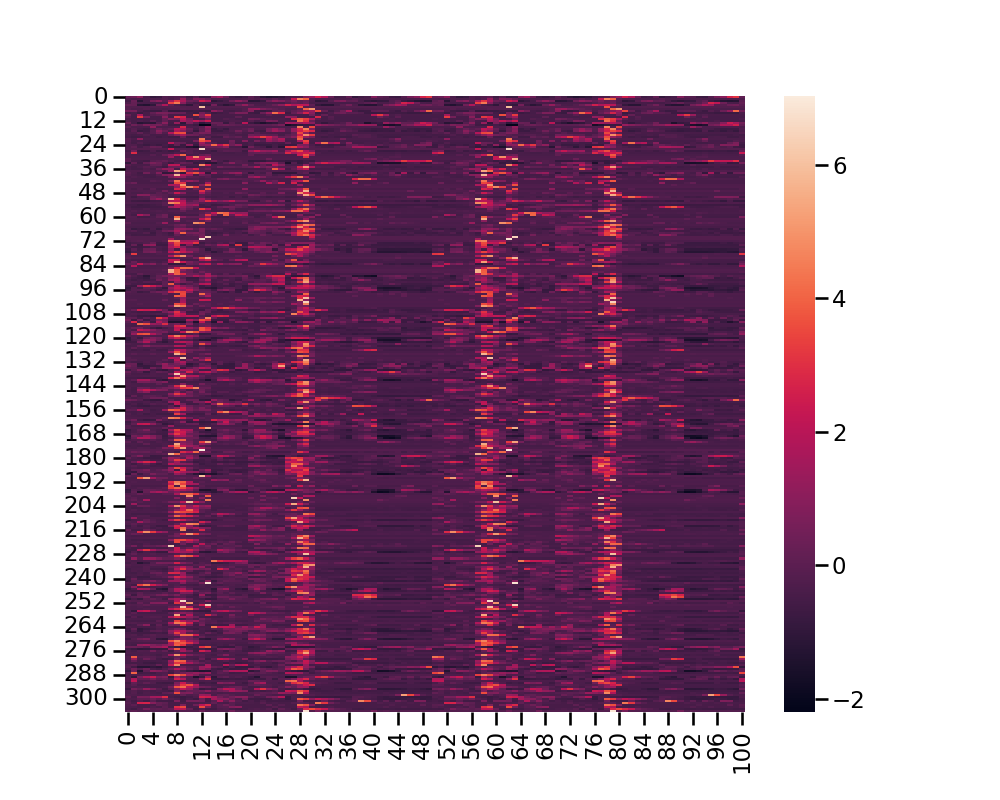

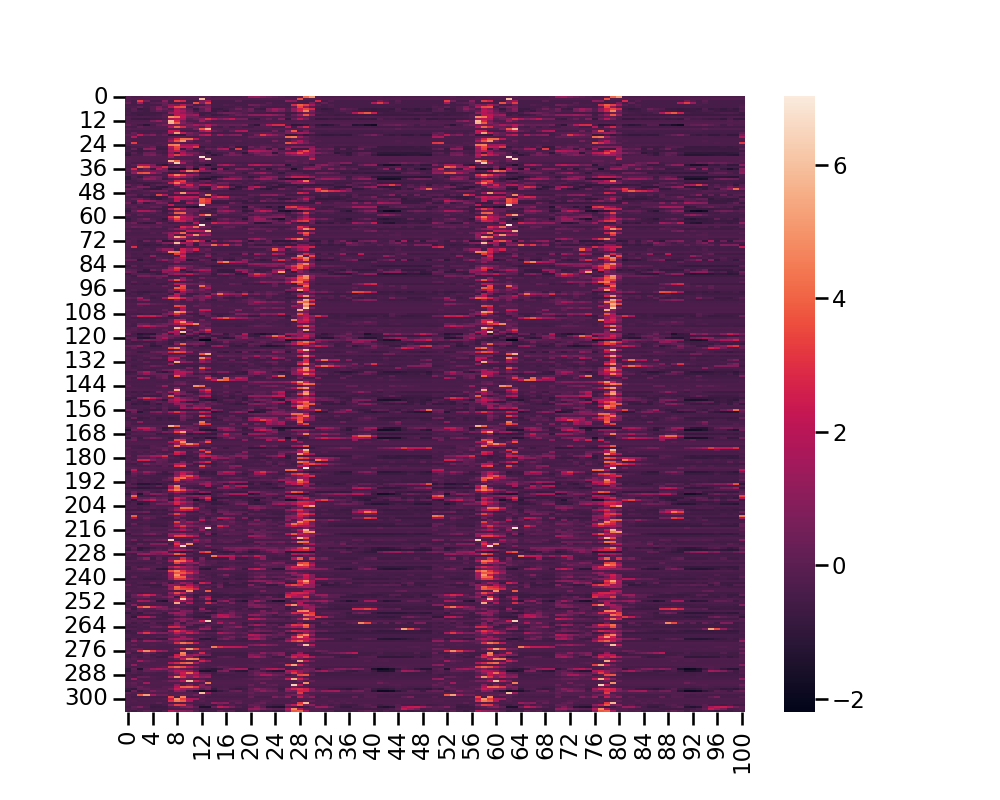

In [81]:
# now we sort the state tuning curves by anatomical order
B_normalized = stats.zscore(B, axis=0)
plt.figure(figsize=(10, 8))
sns.heatmap(B_normalized.T)
plt.show()

# now sort the emissions matrix by the anatomical positions
B_sorted_by_anatomy = B[:, anatomical_sort_order]
B_sorted_by_anatomy_normalized = stats.zscore(B_sorted_by_anatomy, axis=0)

plt.figure(figsize=(10, 8))
sns.heatmap(B_sorted_by_anatomy_normalized.T)
plt.show()


In [82]:
# now we can get for each state the anatomical tuning of the units that are most active in that state, by looking at the emission matrix B and finding the units with the highest emission probabilities for each state, and then looking up their shank and probe IDs.
anatomical_tuning = np.zeros((B.shape[0], n_anatomical_positions))

# normalize the tuning of each neuron across states to get a z-score for each neuron, so that we can compare the anatomical tuning across states.
B_normalized = stats.zscore(B, axis=1)

for state in range(B.shape[0]):
    # normalize the emission probabilities for this state
    state_emission = B_normalized[state]
    
    # get the indices of the top 10% most active units for this state
    top_units_idx = np.argsort(state_emission)[-int(0.1 * len(state_emission)):]
    
    # get the anatomical positions of these top units
    top_anatomical_positions = anatomical_order[top_units_idx]
    
    # compute the histogram of anatomical positions for these top units
    hist, _ = np.histogram(top_anatomical_positions, bins=np.arange(n_anatomical_positions + 1), density=True)
    
    anatomical_tuning[state] = hist



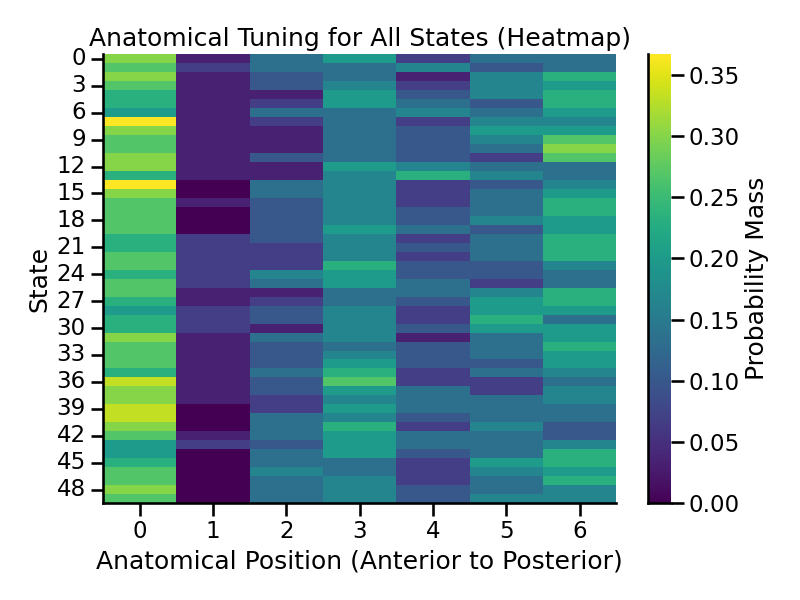

In [83]:
# plot the anatomical tuning of each state as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(anatomical_tuning[:50], cmap="viridis", cbar_kws={'label': 'Probability Mass'})
plt.title("Anatomical Tuning for All States (Heatmap)")
plt.xlabel("Anatomical Position (Anterior to Posterior)")
plt.ylabel("State")
plt.tight_layout()
sns.despine()
plt.show()

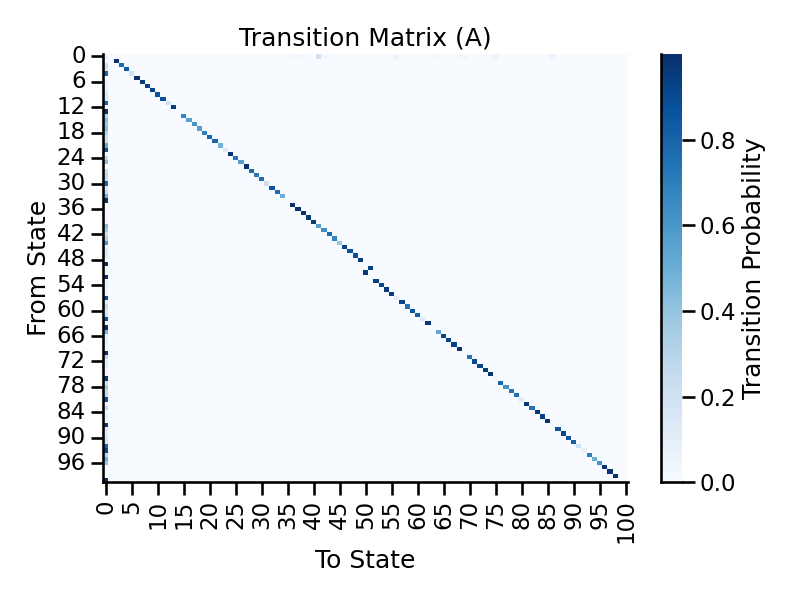

Number of cloned states: 50


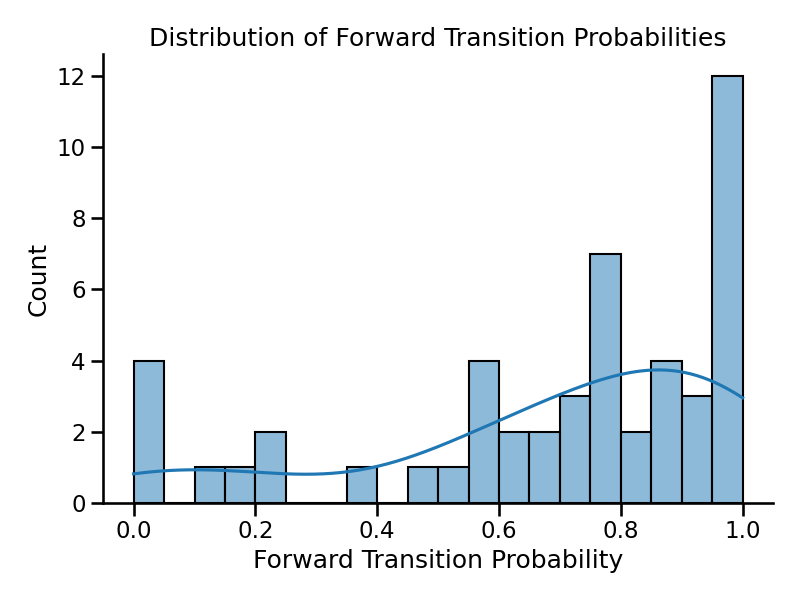

Found 6 sequence boundaries at cloned states: [ 0 11 13 22 34 49]
Sequence intervals: [(np.int64(0), np.int64(11)), (np.int64(11), np.int64(13)), (np.int64(13), np.int64(22)), (np.int64(22), np.int64(34)), (np.int64(34), np.int64(49))]


In [84]:
# plot the A matrix 
plt.figure(figsize=(8, 6))
sns.heatmap(A, cmap="Blues", cbar_kws={'label': 'Transition Probability'})
plt.title("Transition Matrix (A)")
plt.xlabel("To State")
plt.ylabel("From State")
plt.tight_layout()
sns.despine()
plt.show()


# find the values that are less than 0.2 which are sequence boundaries
nClonedStates = (A.shape[0] - 1) // 2
print(f"Number of cloned states: {nClonedStates}")
transition_probs_forward = np.zeros((nClonedStates))

for i in range(nClonedStates):
    transition_probs_forward[i] = A[i, i + 1]


# plot the distirbution of forward transition probabilities
plt.figure(figsize=(8, 6))
sns.histplot(transition_probs_forward, bins=20, kde=True)
plt.title("Distribution of Forward Transition Probabilities")
plt.xlabel("Forward Transition Probability")
plt.ylabel("Count")
plt.tight_layout()
sns.despine()
plt.show()

# get the indices of the cloned states that have forward transition probabilities less than 0.2
sequence_boundaries = np.where(transition_probs_forward < 0.2)[0]
print(f"Found {len(sequence_boundaries)} sequence boundaries at cloned states: {sequence_boundaries}")

# make a list of intervals between the sequence boundaries
sequence_intervals = []
for i in range(len(sequence_boundaries) - 1):
    start = sequence_boundaries[i]
    end = sequence_boundaries[i + 1]
    sequence_intervals.append((start, end))

print(f"Sequence intervals: {sequence_intervals}")


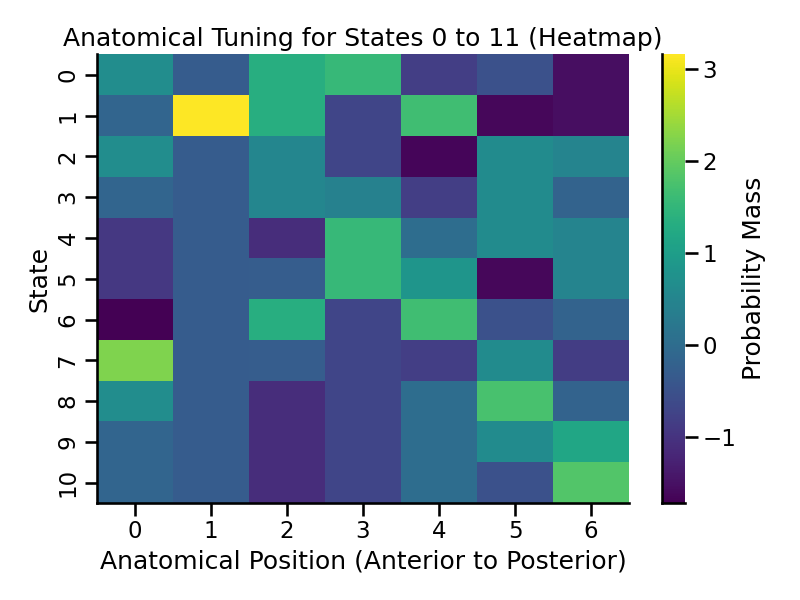

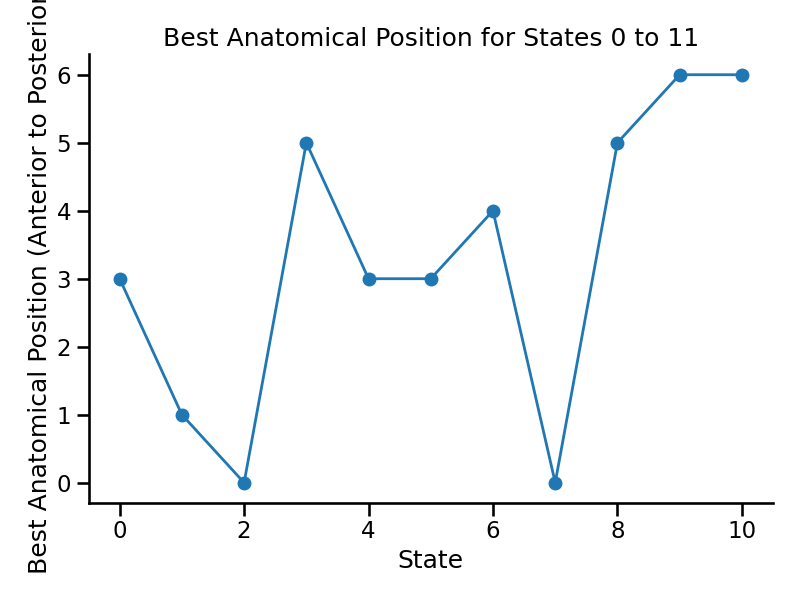

/tmp/ipykernel_1785401/3147746412.py:4: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sns.heatmap(stats.zscore(anatomical_tuning[start:end], axis=0), cmap="viridis", cbar_kws={'label': 'Probability Mass'})


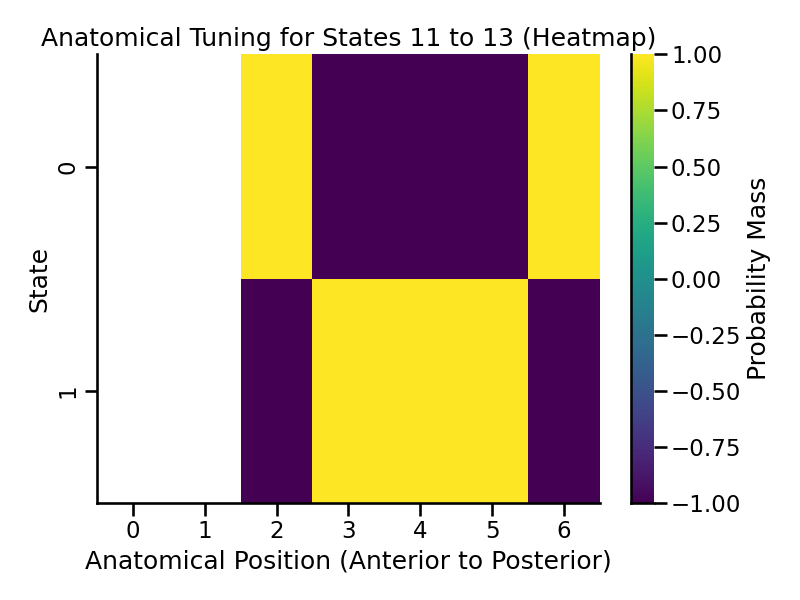

/tmp/ipykernel_1785401/3147746412.py:14: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  best_anatomical_position_per_state = np.argmax(stats.zscore(anatomical_tuning[start:end], axis=0), axis=1)


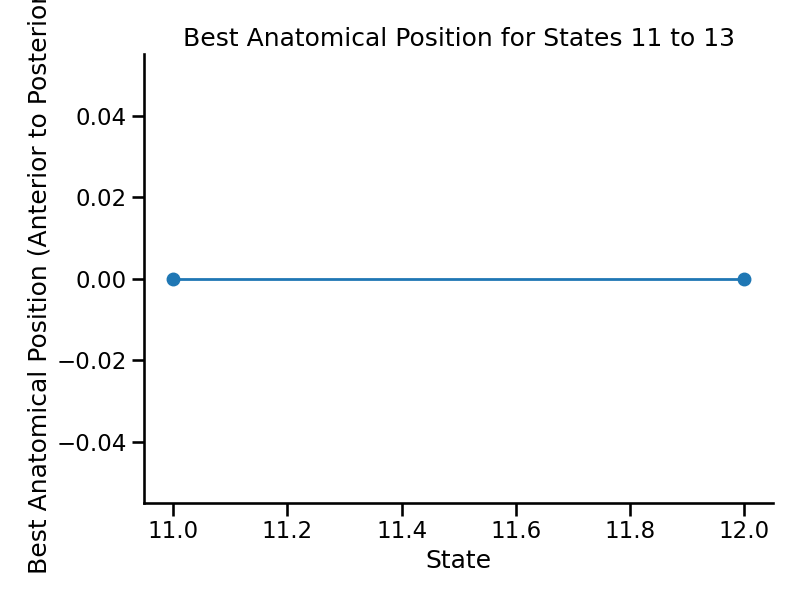

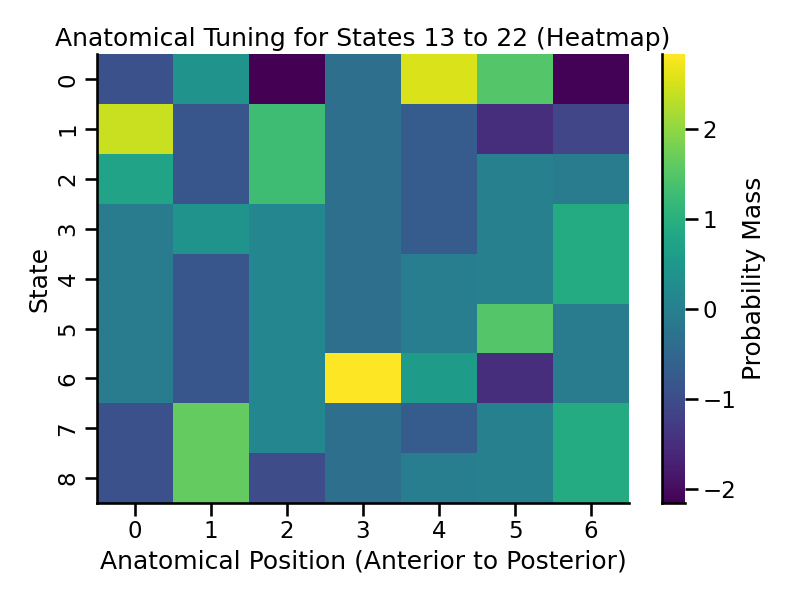

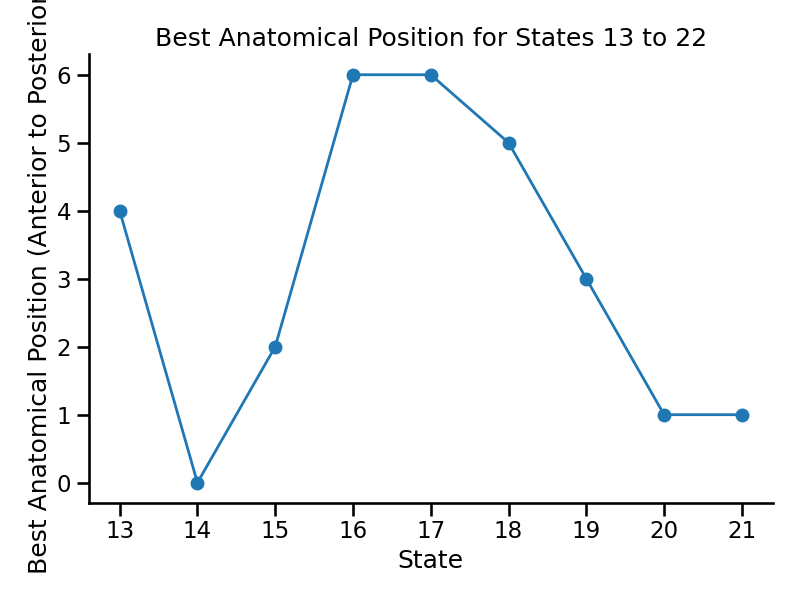

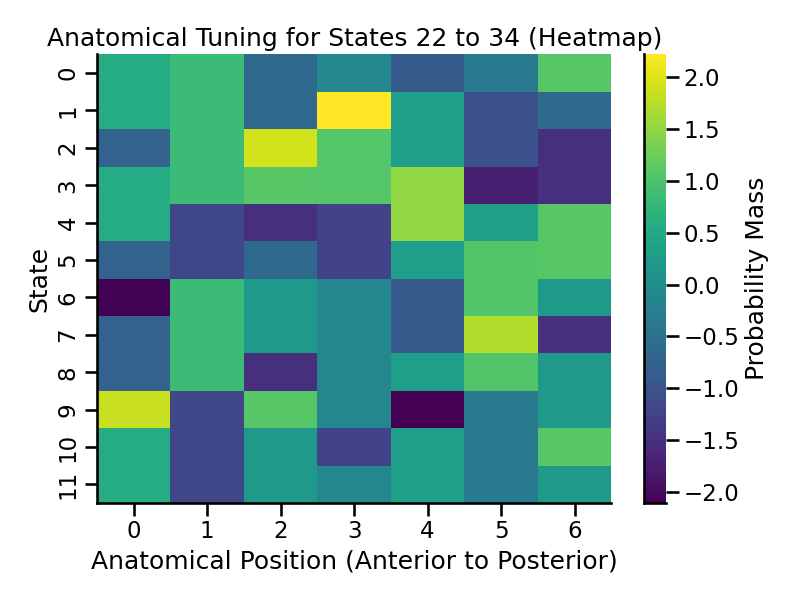

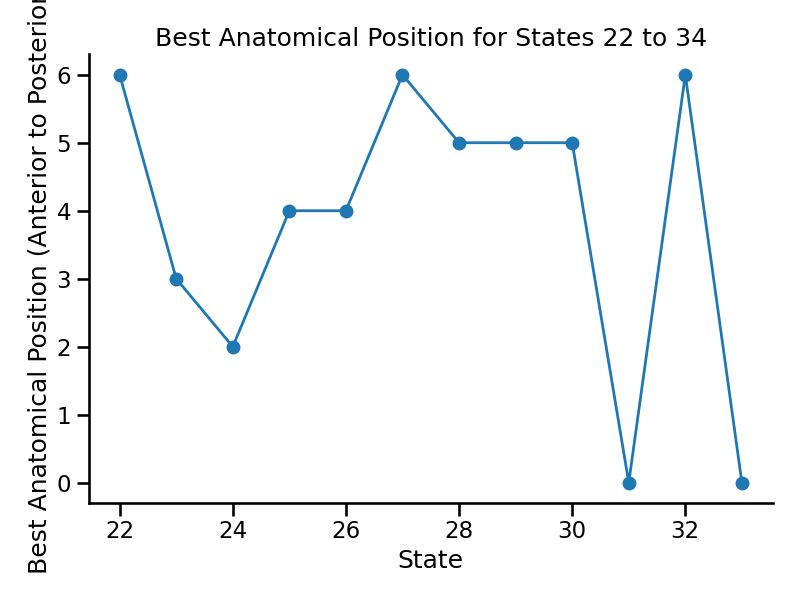

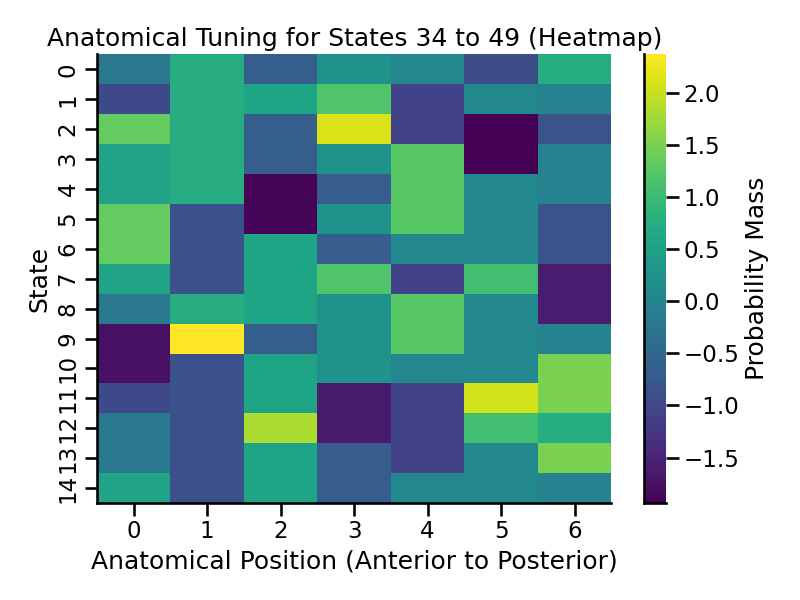

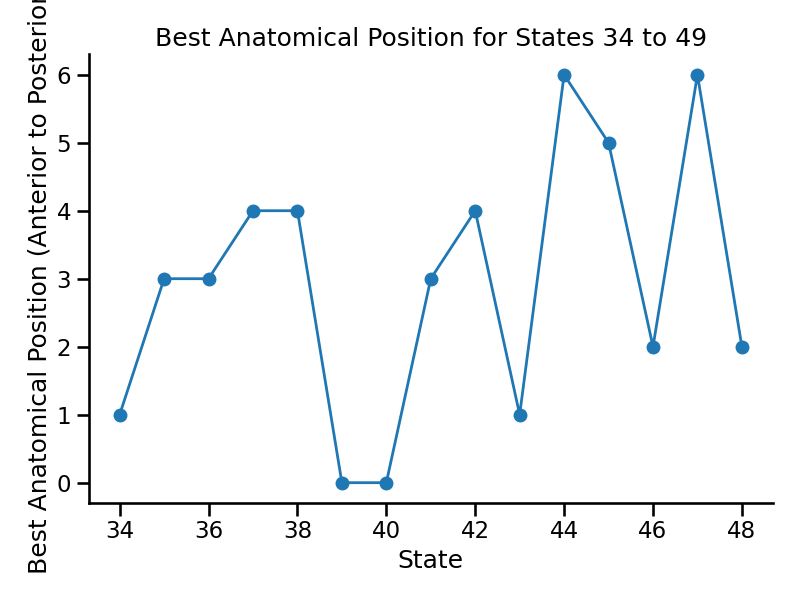

In [85]:
# for each sequence interval plot the heatmap of the anatomical tuning of the states in that interval
for interval_idx, (start, end) in enumerate(sequence_intervals):
    plt.figure(figsize=(8, 6))
    sns.heatmap(stats.zscore(anatomical_tuning[start:end], axis=0), cmap="viridis", cbar_kws={'label': 'Probability Mass'})
    plt.title(f"Anatomical Tuning for States {start} to {end} (Heatmap)")
    plt.xlabel("Anatomical Position (Anterior to Posterior)")
    plt.ylabel("State")
    plt.tight_layout()
    sns.despine()
    plt.show()

    state_ind = np.arange(start, end)

    best_anatomical_position_per_state = np.argmax(stats.zscore(anatomical_tuning[start:end], axis=0), axis=1)
    #plot line plot of the best anatomical tuning for each state in this interval
    plt.figure(figsize=(8, 6))
    plt.plot(state_ind,best_anatomical_position_per_state, marker='o', linewidth=2)
    plt.title(f"Best Anatomical Position for States {start} to {end}")
    plt.xlabel("State")
    plt.ylabel("Best Anatomical Position (Anterior to Posterior)")
    plt.tight_layout()
    sns.despine()
    plt.show()

